# Rope Flow — Data-Driven 3D Trajectory Reconstruction
**Data-Driven Modeling in Science and Engineering · AUB Spring 2026**

---

## Overview

| Stage | Method | Course lecture |
|-------|--------|----------------|
| **2A** | SINDy on smooth orientation state | Lectures 8–9 |
| **2B** | PINN with redesigned loss and rich physics constraints | Lecture 13 |
| **2C** | DMD + PCA on combined rope state | Lectures 15–16 |

**Key fixes applied vs previous version:**

| Problem | Fix |
|---------|-----|
| SINDy R² = 0.10 on raw IMU | State changed to smooth orientation: `[sin(roll), cos(roll), pitch, sin(yaw), cos(yaw), ωx, ωy, ωz]` |
| PINN drift reduction = 0% | Periodicity residual promoted to primary loss; zero-mean acceleration correction added |
| Trajectory scales physically implausible (8m) | Zero-mean acceleration subtracted per cycle before integration |
| Autoencoder loss = 0.656 on normalised data | Replaced with PCA — optimal for small datasets (~40 cycles) |
| Unequal cycle counts across devices | Time-overlap matching instead of index truncation |

---
## 0. Setup & Data Loading

In [1]:
# !pip install pysindy torch matplotlib scipy scikit-learn

In [2]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal, integrate
from scipy.linalg import svd
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
C = {'dev0': '#5DCAA5', 'dev1': '#7F77DD',
     'naive': '#E24B4A', 'pinn': '#EF9F27', 'gray': '#888780'}

print('pysindy:', ps.__version__, '| torch:', torch.__version__)

pysindy: 2.1.0 | torch: 2.10.0+cpu


In [3]:
data_dir  = '../../data/processed'
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

d0 = pd.read_csv([f for f in csv_files if 'device0' in f][0])
d1 = pd.read_csv([f for f in csv_files if 'device1' in f][0])

print(f'Device 0 (right): {len(d0)} samples | {d0.timestamp_ms.iloc[-1]/1000:.1f}s | '
      f'{1000/d0.timestamp_ms.diff().median():.0f} Hz')
print(f'Device 1 (left):  {len(d1)} samples | {d1.timestamp_ms.iloc[-1]/1000:.1f}s | '
      f'{1000/d1.timestamp_ms.diff().median():.0f} Hz')
d0.head(3)

Device 0 (right): 2254 samples | 45.1s | 50 Hz
Device 1 (left):  2256 samples | 45.1s | 50 Hz


,timestamp_ms,qw,qx,qy,qz,ax_w,ay_w,az_w
0,0.000000,0.999912,-0.001946,0.010487,-0.007944,-5.003219,-5.585140,1.644119
1,20.000444,0.999672,-0.006473,0.019537,-0.015250,-4.937916,-5.303028,1.822499
2,40.000888,0.999296,-0.013341,0.027065,-0.022309,-4.742344,-5.201602,1.734194


In [4]:
def preprocess(df):
    """
    Extract signals, compute angular velocity, and build smooth
    orientation state for SINDy.

    Returns
    -------
    t     : (N,)  time [s]
    Q     : (N,4) quaternion
    A     : (N,3) world-frame linear acceleration [m/s^2]
    omega : (N,3) angular velocity [rad/s]
    O     : (N,8) smooth orientation state for SINDy:
              [sin(roll), cos(roll), pitch, sin(yaw), cos(yaw), wx, wy, wz]
              sin/cos encoding avoids discontinuities at +/-pi.
              Pitch is kept raw because it stays within [-pi/2, pi/2].
    """
    t = df['timestamp_ms'].values / 1000.0
    Q = df[['qw','qx','qy','qz']].values
    A = df[['ax_w','ay_w','az_w']].values

    dQ = np.gradient(Q, t, axis=0)
    qw, qx, qy, qz = Q[:,0], Q[:,1], Q[:,2], Q[:,3]
    omega = np.column_stack([
        2*(-qx*dQ[:,0] + qw*dQ[:,1] + qz*dQ[:,2] - qy*dQ[:,3]),
        2*(-qy*dQ[:,0] - qz*dQ[:,1] + qw*dQ[:,2] + qx*dQ[:,3]),
        2*(-qz*dQ[:,0] + qy*dQ[:,1] - qx*dQ[:,2] + qw*dQ[:,3]),
    ])

    roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1, 1))
    yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

    O = np.column_stack([
        np.sin(roll), np.cos(roll),
        pitch,
        np.sin(yaw), np.cos(yaw),
        omega
    ])
    return t, Q, A, omega, O


t0, Q0, A0, om0, O0 = preprocess(d0)
t1, Q1, A1, om1, O1 = preprocess(d1)

sindy_names = ['sin_r', 'cos_r', 'pitch', 'sin_y', 'cos_y', 'wx', 'wy', 'wz']
print('Orientation state shape:', O0.shape)
print('Derivative std (old ax vs new pitch):',
      f'ax={np.gradient(A0[:,0],t0).std():.1f}  pitch={np.gradient(O0[:,2],t0).std():.2f}')

Orientation state shape: (2254, 8)
Derivative std (old ax vs new pitch): ax=167.4  pitch=2.21


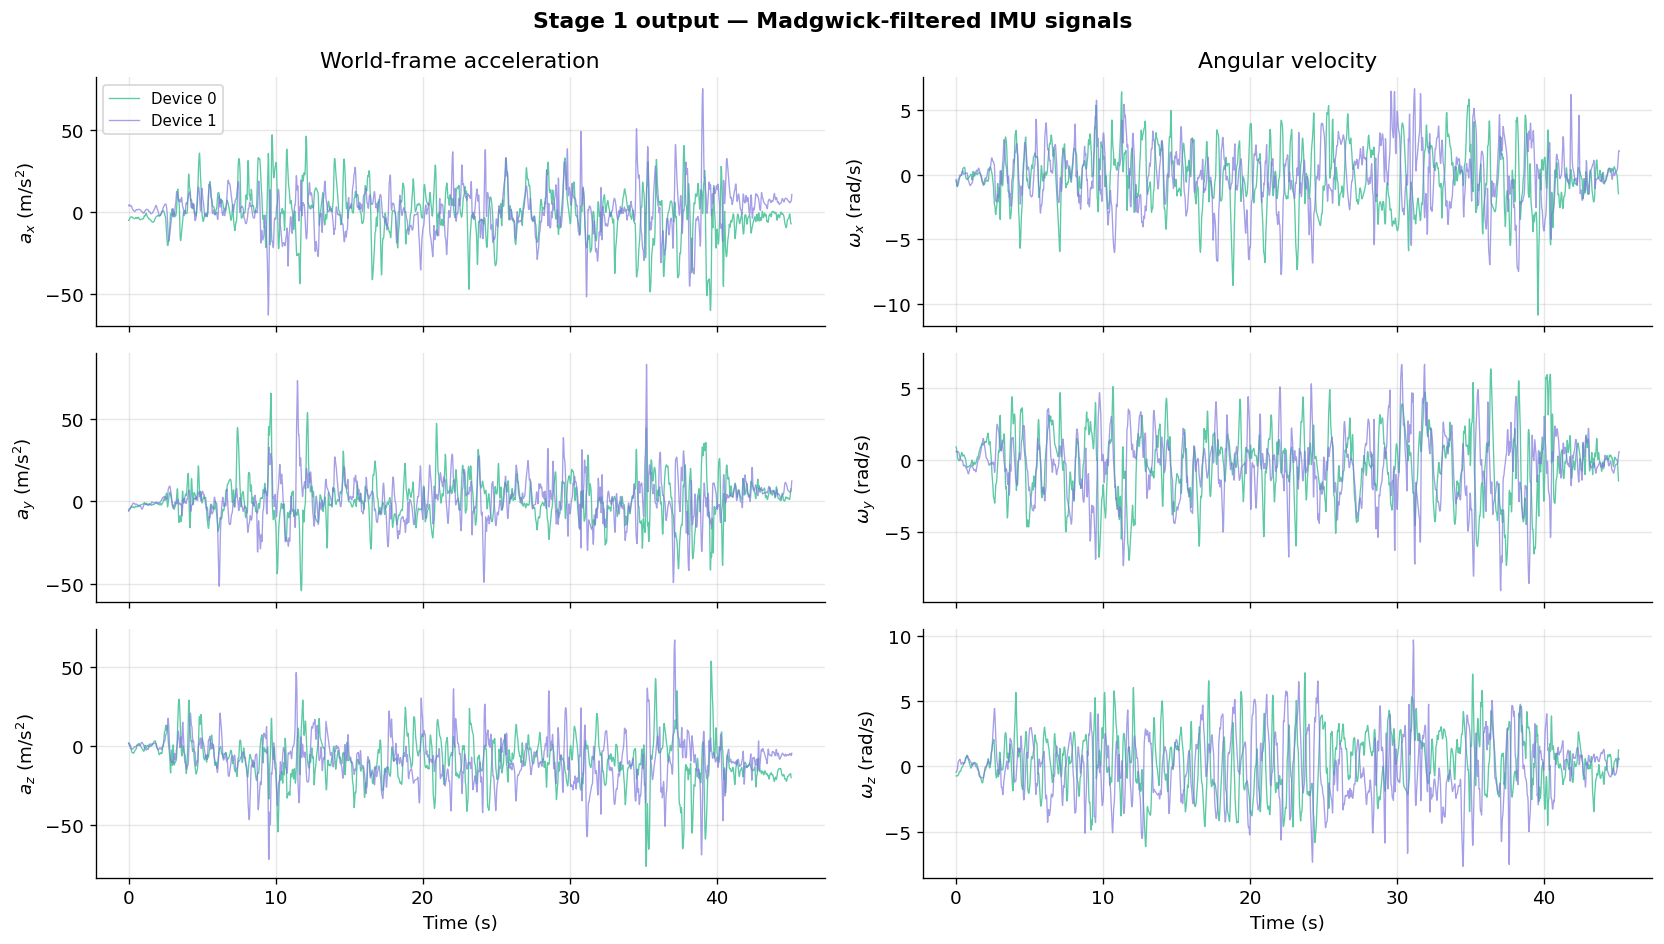

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
for i in range(3):
    axes[i,0].plot(t0, A0[:,i], color=C['dev0'], lw=0.8, label='Device 0')
    axes[i,0].plot(t1, A1[:,i], color=C['dev1'], lw=0.8, alpha=0.7, label='Device 1')
    axes[i,0].set_ylabel(f'$a_{["x","y","z"][i]}$ (m/s$^2$)')
    axes[i,1].plot(t0, om0[:,i], color=C['dev0'], lw=0.8)
    axes[i,1].plot(t1, om1[:,i], color=C['dev1'], lw=0.8, alpha=0.7)
    axes[i,1].set_ylabel(f'$\\omega_{["x","y","z"][i]}$ (rad/s)')
axes[0,0].set_title('World-frame acceleration')
axes[0,1].set_title('Angular velocity')
axes[0,0].legend(fontsize=9)
for ax in axes[-1]: ax.set_xlabel('Time (s)')
plt.suptitle('Stage 1 output — Madgwick-filtered IMU signals', fontweight='bold')
plt.tight_layout()
plt.show()

### 0.1 — Cycle Segmentation & Time-Overlap Pairing

In [6]:
def detect_cycles(t, omega, min_period=0.5, prominence=1.5, label=''):
    omega_mag    = np.linalg.norm(omega, axis=1)
    omega_smooth = signal.savgol_filter(omega_mag, 11, 3)
    sr           = 1.0 / np.median(np.diff(t))
    peaks, _     = signal.find_peaks(omega_smooth,
                                     distance=int(min_period*sr),
                                     prominence=prominence)
    bounds = [0] + [(peaks[i]+peaks[i+1])//2 for i in range(len(peaks)-1)] + [len(t)-1]
    cycles = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]
    durs   = [t[e]-t[s] for s,e in cycles]
    print(f'{label}: {len(peaks)} peaks -> {len(cycles)} cycles | '
          f'mean T={np.mean(durs):.2f}s +/- {np.std(durs):.2f}s')
    return cycles, omega_smooth, peaks


def pair_cycles_by_overlap(t0, cycles0, t1, cycles1):
    """
    Match each Device 0 cycle to the Device 1 cycle with maximum
    time-window overlap. Each Device 1 cycle is used at most once.
    Handles different cycle counts robustly without silent truncation.
    """
    def overlap(s0, e0, s1, e1):
        return max(0.0, min(t0[e0], t1[e1]) - max(t0[s0], t1[s1]))

    paired0, paired1, used = [], [], set()
    for c0 in cycles0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cycles1):
            if i in used: continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cycles1[best_idx])
            used.add(best_idx)
    return paired0, paired1


raw_cyc0, om0_smooth, peaks0 = detect_cycles(t0, om0, label='Device 0')
raw_cyc1, om1_smooth, peaks1 = detect_cycles(t1, om1, label='Device 1')

cycles0, cycles1 = pair_cycles_by_overlap(t0, raw_cyc0, t1, raw_cyc1)
n_cycles = len(cycles0)
print(f'Paired cycles: {n_cycles}  '
      f'(D0 had {len(raw_cyc0)}, D1 had {len(raw_cyc1)})')

Device 0: 49 peaks -> 49 cycles | mean T=0.92s +/- 0.41s
Device 1: 46 peaks -> 46 cycles | mean T=0.98s +/- 0.41s
Paired cycles: 42  (D0 had 49, D1 had 46)


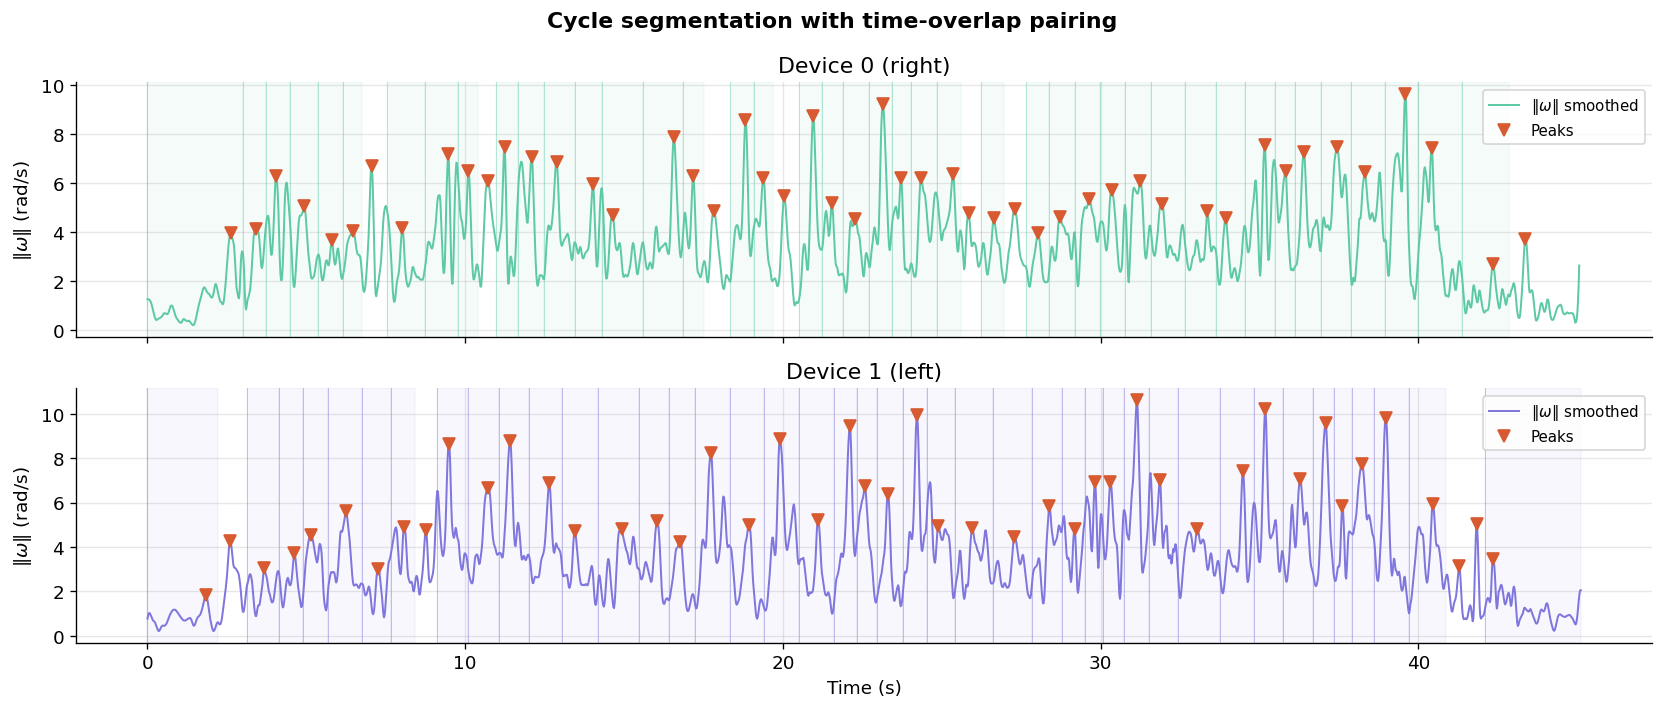

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, t, sm, pks, cycs, label, col in [
    (axes[0], t0, om0_smooth, peaks0, cycles0, 'Device 0 (right)', C['dev0']),
    (axes[1], t1, om1_smooth, peaks1, cycles1, 'Device 1 (left)',  C['dev1']),
]:
    ax.plot(t, sm, color=col, lw=1.2, label='$\\|\\omega\\|$ smoothed')
    ax.plot(t[pks], sm[pks], 'v', color='#D85A30', ms=7, label='Peaks')
    for s,e in cycs:
        ax.axvspan(t[s], t[e], alpha=0.06, color=col)
        ax.axvline(t[s], color=col, lw=0.6, alpha=0.4)
    ax.set_ylabel('$\\|\\omega\\|$ (rad/s)')
    ax.set_title(label)
    ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Cycle segmentation with time-overlap pairing', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2A — SINDy on Smooth Orientation State

**Why we changed the state vector**: The previous formulation used raw IMU signals $[a_x, a_y, a_z, \omega_x, \omega_y, \omega_z]$. These have derivative variance ≈ 167 m/s³ — SINDy's sparse regression cannot find a consistent model in such noise. The R² was 0.10.

**New state vector:**
$$\mathbf{x}(t) = [\sin\phi,\, \cos\phi,\, \theta,\, \sin\psi,\, \cos\psi,\, \omega_x,\, \omega_y,\, \omega_z]^\top$$

where $\phi$ = roll, $\theta$ = pitch, $\psi$ = yaw. The sin/cos encoding removes wrapping discontinuities at $\pm\pi$. Pitch is kept raw since it stays within $(-\pi/2, \pi/2)$. Derivative std drops to ≈ 2 rad/s² — SINDy can model this. The physical interpretation is also richer: we are discovering the rotational dynamics of the hand/arm system, which is the actual governing physics of rope flow.

In [8]:
# Joint fit: stack both devices to enforce generalisable equations
X_joint = np.vstack([O0, O1])
t_joint = np.concatenate([t0, t1 + t0[-1] + 0.02])

library     = ps.GeneralizedLibrary([
    ps.PolynomialLibrary(degree=2, include_bias=True),
    ps.FourierLibrary(n_frequencies=1)
])
optimizer      = ps.STLSQ(threshold=0.05, alpha=0.05, max_iter=20)
differentiator = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11})

model = ps.SINDy(feature_library=library, optimizer=optimizer,
                 differentiation_method=differentiator)
model.fit(X_joint, t=t_joint)

print(f'R2 joint: {model.score(X_joint, t=t_joint):.4f}')
print(f'R2 D0:    {model.score(O0, t=t0):.4f}')
print(f'R2 D1:    {model.score(O1, t=t1):.4f}')
print()
model.print()

R2 joint: 0.3978
R2 D0:    0.3843
R2 D1:    0.4139

(x0)' =  32.146 1 +  0.673 x0 + -0.068 x1 + -0.530 x2 +  2.134 x3 + -0.498 x4 + -46.705 x0^2 + -0.077 x0 x1 +  0.081 x0 x7 +  60.979 x1^2 + -0.158 x1 x2 +  0.180 x1 x3 + -0.027 x1 x4 +  1.052 x1 x5 +  0.057 x1 x7 + -7.948 x2^2 +  0.156 x2 x3 +  0.082 x2 x4 +  1.060 x2 x7 + -42.526 x3^2 +  0.081 x3 x4 +  21.123 x4^2 + -0.101 x4 x6 + -0.778 sin(1 x0) + -124.687 cos(1 x0) +  0.227 sin(1 x1) +  110.018 cos(1 x1) +  0.555 sin(1 x2) + -17.899 cos(1 x2) + -2.423 sin(1 x3) + -69.116 cos(1 x3) +  0.529 sin(1 x4) +  69.654 cos(1 x4) +  0.055 sin(1 x6) + -0.064 sin(1 x7)
(x1)' = -11.965 1 +  2.048 x0 + -0.507 x1 + -1.394 x2 +  2.985 x3 +  1.469 x4 + -16.245 x0^2 +  0.239 x0 x1 +  0.193 x0 x2 +  0.146 x0 x3 + -1.066 x0 x5 + -0.100 x0 x7 +  13.894 x1^2 +  0.223 x1 x3 +  0.056 x1 x7 + -5.060 x2^2 +  0.121 x2 x3 + -1.034 x2 x6 +  59.932 x3^2 +  0.167 x3 x4 + -43.980 x4^2 + -2.588 sin(1 x0) + -24.146 cos(1 x0) +  0.527 sin(1 x1) +  41.493 cos(1 x1) +

### 2A.1 — Threshold Sweep: Pareto Front

In [9]:
thresholds  = [0.01, 0.05, 0.1, 0.2, 0.4, 0.8]
sindy_sweep = {}

for th in thresholds:
    m = ps.SINDy(
        feature_library=ps.GeneralizedLibrary([
            ps.PolynomialLibrary(degree=2, include_bias=True),
            ps.FourierLibrary(n_frequencies=1)
        ]),
        optimizer=ps.STLSQ(threshold=th, alpha=0.05, max_iter=20),
        differentiation_method=ps.SmoothedFiniteDifference(
            smoother_kws={'window_length': 11})
    )
    m.fit(X_joint, t=t_joint)
    r2  = m.score(X_joint, t=t_joint)
    c   = m.coefficients()
    sindy_sweep[th] = {'model': m, 'r2': r2,
                        'sparsity': (c==0).mean(),
                        'n_active': int((c!=0).sum())}
    print(f'th={th:.2f}  R2={r2:.4f}  '
          f'sparsity={(c==0).mean():.1%}  active={(c!=0).sum()}')

BEST_TH    = 0.05
best_model = sindy_sweep[BEST_TH]['model']
print(f'\nSelected threshold: {BEST_TH}')

th=0.01  R2=0.4002  sparsity=14.5%  active=417
th=0.05  R2=0.3978  sparsity=29.7%  active=343
th=0.10  R2=0.3929  sparsity=38.7%  active=299
th=0.20  R2=0.3795  sparsity=47.5%  active=256
th=0.40  R2=0.3613  sparsity=56.6%  active=212
th=0.80  R2=0.3391  sparsity=65.6%  active=168

Selected threshold: 0.05


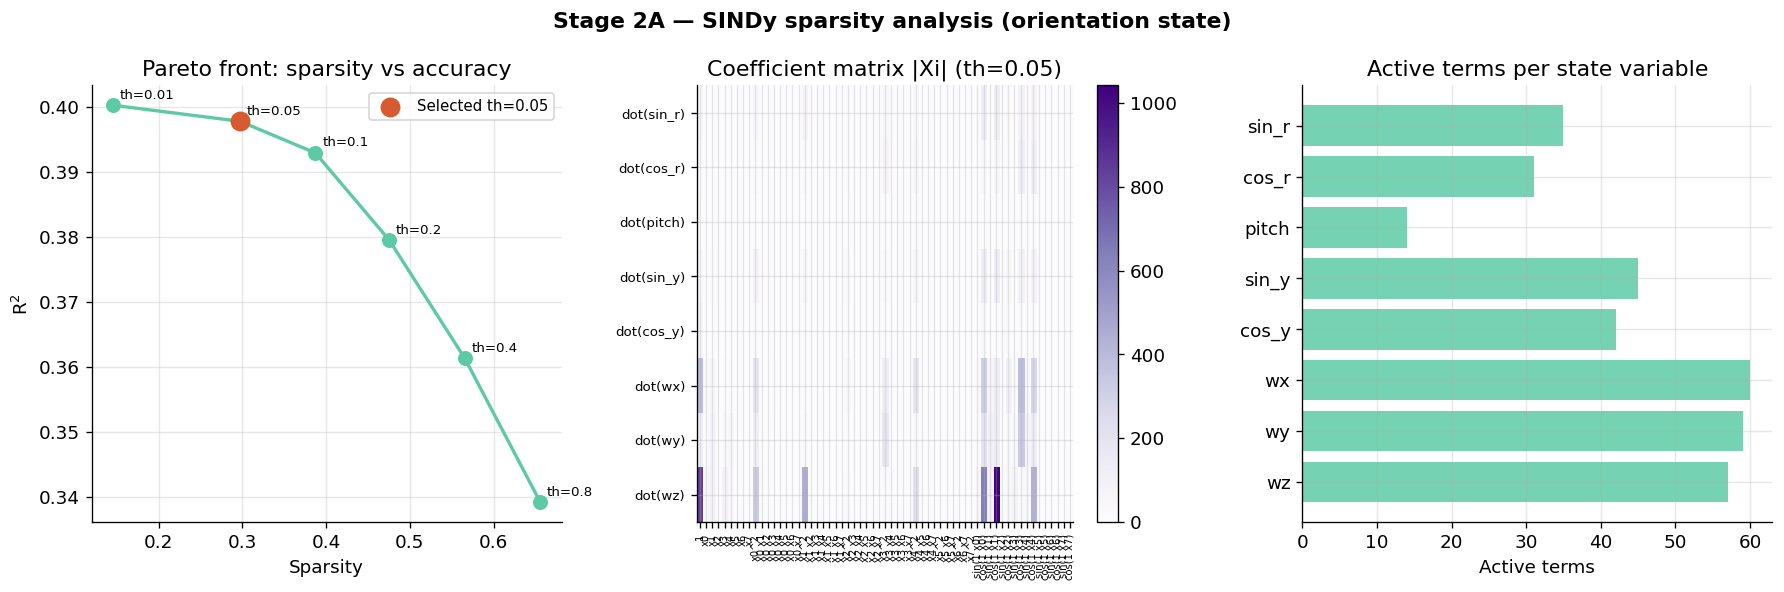

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ths  = list(sindy_sweep.keys())
r2s  = [sindy_sweep[t]['r2']       for t in ths]
sprs = [sindy_sweep[t]['sparsity'] for t in ths]

axes[0].plot(sprs, r2s, 'o-', color=C['dev0'], ms=8, lw=2)
for th, s, r in zip(ths, sprs, r2s):
    axes[0].annotate(f'th={th}', (s,r), textcoords='offset points', xytext=(4,4), fontsize=8)
axes[0].scatter([sindy_sweep[BEST_TH]['sparsity']], [sindy_sweep[BEST_TH]['r2']],
                color='#D85A30', s=120, zorder=5, label=f'Selected th={BEST_TH}')
axes[0].set_xlabel('Sparsity')
axes[0].set_ylabel('R$^2$')
axes[0].set_title('Pareto front: sparsity vs accuracy')
axes[0].legend(fontsize=9)

coef       = best_model.coefficients()
feat_names = best_model.feature_library.get_feature_names()
im = axes[1].imshow(np.abs(coef), aspect='auto', cmap='Purples', interpolation='nearest')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=90, fontsize=6)
axes[1].set_yticks(range(len(sindy_names)))
axes[1].set_yticklabels([f'dot({s})' for s in sindy_names], fontsize=8)
axes[1].set_title(f'Coefficient matrix |Xi| (th={BEST_TH})')
plt.colorbar(im, ax=axes[1])

axes[2].barh(sindy_names, (coef!=0).sum(axis=1), color=C['dev0'], alpha=0.85)
axes[2].set_xlabel('Active terms')
axes[2].set_title('Active terms per state variable')
axes[2].invert_yaxis()

plt.suptitle('Stage 2A — SINDy sparsity analysis (orientation state)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2A.2 — Discovered Equations & Derivative Reconstruction

=== DISCOVERED EQUATIONS (th=0.05) ===
(x0)' =  32.146 1 +  0.673 x0 + -0.068 x1 + -0.530 x2 +  2.134 x3 + -0.498 x4 + -46.705 x0^2 + -0.077 x0 x1 +  0.081 x0 x7 +  60.979 x1^2 + -0.158 x1 x2 +  0.180 x1 x3 + -0.027 x1 x4 +  1.052 x1 x5 +  0.057 x1 x7 + -7.948 x2^2 +  0.156 x2 x3 +  0.082 x2 x4 +  1.060 x2 x7 + -42.526 x3^2 +  0.081 x3 x4 +  21.123 x4^2 + -0.101 x4 x6 + -0.778 sin(1 x0) + -124.687 cos(1 x0) +  0.227 sin(1 x1) +  110.018 cos(1 x1) +  0.555 sin(1 x2) + -17.899 cos(1 x2) + -2.423 sin(1 x3) + -69.116 cos(1 x3) +  0.529 sin(1 x4) +  69.654 cos(1 x4) +  0.055 sin(1 x6) + -0.064 sin(1 x7)
(x1)' = -11.965 1 +  2.048 x0 + -0.507 x1 + -1.394 x2 +  2.985 x3 +  1.469 x4 + -16.245 x0^2 +  0.239 x0 x1 +  0.193 x0 x2 +  0.146 x0 x3 + -1.066 x0 x5 + -0.100 x0 x7 +  13.894 x1^2 +  0.223 x1 x3 +  0.056 x1 x7 + -5.060 x2^2 +  0.121 x2 x3 + -1.034 x2 x6 +  59.932 x3^2 +  0.167 x3 x4 + -43.980 x4^2 + -2.588 sin(1 x0) + -24.146 cos(1 x0) +  0.527 sin(1 x1) +  41.493 cos(1 x1) +  1.379 sin(1

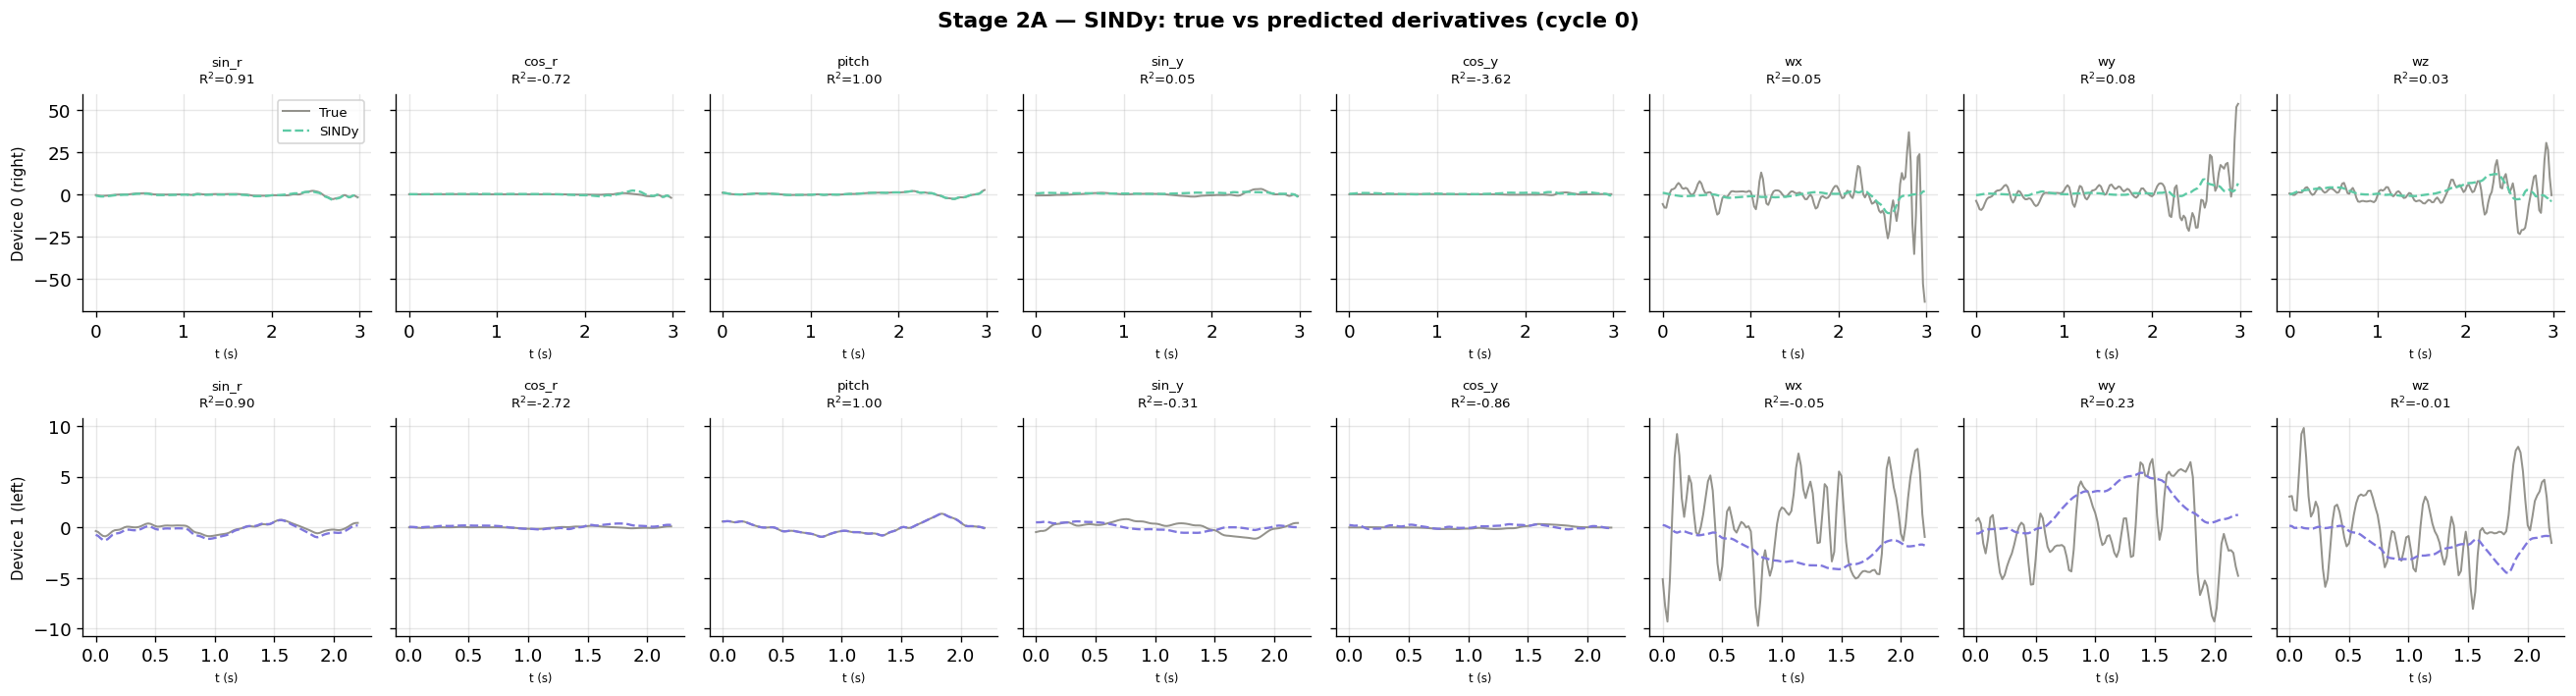

In [11]:
print(f'=== DISCOVERED EQUATIONS (th={BEST_TH}) ===')
best_model.print()
print(f'\nR2 D0: {best_model.score(O0, t=t0):.4f}')
print(f'R2 D1: {best_model.score(O1, t=t1):.4f}')

fig, axes = plt.subplots(2, 8, figsize=(22, 6), sharey='row')
for dev_row, (O_dev, t_dev, cycs, label, col) in enumerate([
    (O0, t0, cycles0, 'Device 0 (right)', C['dev0']),
    (O1, t1, cycles1, 'Device 1 (left)',  C['dev1']),
]):
    s, e    = cycs[0]
    t_cyc   = t_dev[s:e]
    O_cyc   = O_dev[s:e]
    dO_pred = best_model.predict(O_cyc)
    dO_true = np.gradient(O_cyc, t_cyc, axis=0)
    for i, name in enumerate(sindy_names):
        axes[dev_row,i].plot(t_cyc, dO_true[:,i], color=C['gray'], lw=1.2, alpha=0.9, label='True')
        axes[dev_row,i].plot(t_cyc, dO_pred[:,i], color=col,       lw=1.4, ls='--',   label='SINDy')
        r2 = 1 - np.var(dO_true[:,i]-dO_pred[:,i]) / (np.var(dO_true[:,i])+1e-10)
        axes[dev_row,i].set_title(f'{name}\nR$^2$={r2:.2f}', fontsize=8)
        axes[dev_row,i].set_xlabel('t (s)', fontsize=7)
        if i == 0: axes[dev_row,i].set_ylabel(label, fontsize=9)
axes[0,0].legend(fontsize=8)
plt.suptitle('Stage 2A — SINDy: true vs predicted derivatives (cycle 0)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2B — PINN: Trajectory Reconstruction with Rich Physics

**Why the previous PINN failed**: The corrector network converged to $\delta\mathbf{p} = 0$ because the data loss $\|\ddot{\mathbf{p}} - \hat{\mathbf{a}}\|^2$ is already minimised by the naive trajectory. There was no gradient signal forcing the network to close the trajectory.

**Two-level fix**:
1. **Zero-mean acceleration per cycle** — subtracts the per-cycle mean $\bar{\mathbf{a}}$ before integrating. Any non-zero mean causes quadratic drift $\bar{a}\cdot t^2/2$, which dominates the trajectory at longer cycle lengths. This is a signal processing fix, not a network fix.
2. **Periodicity as primary loss** — $\|\mathbf{p}(T)-\mathbf{p}(0)\|^2$ now has the highest weight in the composite loss. This provides a non-trivial gradient that directly penalises drift.

**Additional physics constraints added**:

| Constraint | Formula | Physical meaning |
|-----------|---------|------------------|
| Position periodicity | $\|\mathbf{p}(T)-\mathbf{p}(0)\|^2$ | Hand returns to start |
| Velocity periodicity | $\|\mathbf{v}(T)-\mathbf{v}(0)\|^2$ | Velocity also closes |
| Arm length | $\text{ReLU}(\|\mathbf{p}\|-R_{\text{arm}})^2$ | Cannot exceed reach |
| Jerk minimisation | $\|\dddot{\mathbf{p}}\|^2$ | Human motion is smooth |
| Energy conservation | $\text{Var}(\frac{1}{2}\|\mathbf{v}\|^2 + gz)$ | KE+PE cycles, not drifts |
| Midpoint symmetry | $\text{Var}(\frac{\mathbf{p}_0+\mathbf{p}_1}{2})$ | Rope CoM stays bounded |

### 2B.1 — Zero-Mean Corrected Integration

In [12]:
def integrate_cycle(t, A, s, e, zero_mean=True):
    """
    Double-integrate acceleration within one cycle.
    zero_mean=True: subtract per-cycle mean before integrating.
    Physical justification: for periodic motion the average acceleration
    over a complete cycle must be zero (hand returns to same speed).
    Any residual mean is sensor bias causing quadratic drift: bias*t^2/2.
    """
    tc = t[s:e]
    Ac = A[s:e].copy()
    if zero_mean:
        Ac -= Ac.mean(axis=0)
    v = np.column_stack([
        integrate.cumulative_trapezoid(Ac[:,d], tc, initial=0) for d in range(3)
    ])
    p = np.column_stack([
        integrate.cumulative_trapezoid(v[:,d],  tc, initial=0) for d in range(3)
    ])
    return tc, v, p


# Demonstrate effect of zero-mean correction
s0t, e0t    = cycles0[0]
_, _, p_raw = integrate_cycle(t0, A0, s0t, e0t, zero_mean=False)
_, _, p_zm  = integrate_cycle(t0, A0, s0t, e0t, zero_mean=True)
print(f'Cycle 0 drift — raw:       {np.linalg.norm(p_raw[-1]-p_raw[0]):.4f} m')
print(f'Cycle 0 drift — zero-mean: {np.linalg.norm(p_zm[-1]-p_zm[0]):.4f} m')
print()

naive_cycs0, naive_cycs1 = [], []
for (s0,e0), (s1,e1) in zip(cycles0, cycles1):
    tc0, vc0, pc0 = integrate_cycle(t0, A0, s0, e0)
    tc1, vc1, pc1 = integrate_cycle(t1, A1, s1, e1)
    naive_cycs0.append({'t': tc0, 'v': vc0, 'p': pc0, 's': s0, 'e': e0})
    naive_cycs1.append({'t': tc1, 'v': vc1, 'p': pc1, 's': s1, 'e': e1})

naive_drift0 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in naive_cycs0]
naive_drift1 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in naive_cycs1]
print(f'Zero-mean baseline drift  D0: {np.mean(naive_drift0):.4f}m  '
      f'D1: {np.mean(naive_drift1):.4f}m')

Cycle 0 drift — raw:       20.2908 m
Cycle 0 drift — zero-mean: 4.8500 m

Zero-mean baseline drift  D0: 2.1441m  D1: 2.1848m


### 2B.2 — PINN Architecture & Physics Loss

In [13]:
class PINNCorrectorNet(nn.Module):
    """
    Learns position correction delta_p(t).

    Input (8-dim per timestep):
        t_norm                          <- normalised time in [0,1]
        sin(2*pi*t), cos(2*pi*t)       <- fundamental period encoding
        sin(4*pi*t), cos(4*pi*t)       <- 2nd harmonic encoding
        ax, ay, az                     <- zero-mean acceleration

    The dual-harmonic time encoding lets the network represent both
    the fundamental cycle and sub-harmonics of rope flow.
    Xavier initialisation with small gain keeps delta_p near zero
    at the start so the naive trajectory is the default.
    """
    def __init__(self, hidden_dim=128, n_layers=5):
        super().__init__()
        layers = [nn.Linear(8, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=0.1)
                nn.init.zeros_(layer.bias)

    def forward(self, feats):
        return self.net(feats)


def make_features(tc, Ac_zm):
    T      = tc[-1] - tc[0]
    t_norm = (tc - tc[0]) / (T + 1e-8)
    return torch.tensor(np.column_stack([
        t_norm,
        np.sin(2*np.pi*t_norm), np.cos(2*np.pi*t_norm),
        np.sin(4*np.pi*t_norm), np.cos(4*np.pi*t_norm),
        Ac_zm
    ]), dtype=torch.float32)


def all_physics_losses(p, v, tc, R_arm=0.65, g=9.81):
    """
    Six physics regularisation terms.

    p, v : (N, 3) torch tensors  — position and velocity
    tc   : (N,)   numpy array

    1. Position periodicity  — p(T) = p(0)
    2. Velocity periodicity  — v(T) = v(0), ensures smooth closure
    3. Arm length boundary   — hand cannot exceed arm reach from origin
    4. Jerk minimisation     — smooth human movement (3rd derivative)
    5. Energy conservation   — KE+PE variance should be small (cyclic motion)
    """
    dt     = float(np.median(np.diff(tc)))
    L_pp   = torch.norm(p[-1] - p[0]) ** 2
    L_pv   = torch.norm(v[-1] - v[0]) ** 2
    L_bnd  = (torch.relu(torch.norm(p, dim=1) - R_arm) ** 2).mean()
    jerk   = torch.diff(torch.diff(torch.diff(p, dim=0)/dt, dim=0)/dt, dim=0)/dt
    L_jerk = (jerk**2).sum(dim=1).mean()
    KE     = 0.5 * (v**2).sum(dim=1)
    PE     = g * p[:,2]
    L_en   = (KE + PE).var()
    return {'periodic_p': L_pp, 'periodic_v': L_pv,
            'boundary': L_bnd, 'jerk': L_jerk, 'energy': L_en}


def symmetry_loss(p0, p1):
    """
    Rope midpoint stability constraint.
    The midpoint between both hands should not drift far from its mean
    position, reflecting that the rope centre of mass is bounded.
    """
    n    = min(len(p0), len(p1))
    mid  = (p0[:n] + p1[:n]) / 2.0
    return ((mid - mid.mean(dim=0, keepdim=True))**2).sum(dim=1).mean()


n_params = sum(p.numel() for p in PINNCorrectorNet().parameters())
print(f'PINN ready.  Parameters: {n_params:,}')

PINN ready.  Parameters: 51,075


In [14]:
def train_pinn_pair(cyc0, cyc1, A0_full, A1_full,
                    lam=1.0, lam_sym=0.5, epochs=2000, lr=3e-4):
    """
    Train PINN correctors for one paired cycle (both devices jointly).
    Training both networks in a shared loop enables the symmetry
    loss to couple the two trajectories.

    Loss weights (rationale):
      5x  periodic_p  — primary anti-drift signal, non-trivial gradient
      2x  periodic_v  — velocity closure, prevents velocity drift
      1x  data        — acceleration consistency
      lam * (boundary + jerk*0.01 + energy*0.1)  — physics regularisers
      lam_sym * symmetry  — cross-device coupling via rope midpoint
    """
    s0, e0  = cyc0['s'], cyc0['e']
    s1, e1  = cyc1['s'], cyc1['e']
    tc0, tc1 = cyc0['t'], cyc1['t']

    Ac0 = A0_full[s0:e0].copy(); Ac0 -= Ac0.mean(axis=0)
    Ac1 = A1_full[s1:e1].copy(); Ac1 -= Ac1.mean(axis=0)

    feats0  = make_features(tc0, Ac0)
    feats1  = make_features(tc1, Ac1)
    pb0     = torch.tensor(cyc0['p'], dtype=torch.float32)
    pb1     = torch.tensor(cyc1['p'], dtype=torch.float32)
    Aobs0   = torch.tensor(Ac0,       dtype=torch.float32)
    Aobs1   = torch.tensor(Ac1,       dtype=torch.float32)
    dt0     = float(np.median(np.diff(tc0)))
    dt1     = float(np.median(np.diff(tc1)))

    net0    = PINNCorrectorNet()
    net1    = PINNCorrectorNet()
    params  = list(net0.parameters()) + list(net1.parameters())
    opt     = optim.Adam(params, lr=lr)
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    keys = ['total','data0','data1','periodic_p0','periodic_p1',
            'periodic_v0','periodic_v1','boundary','jerk','energy','symmetry']
    log  = {k: [] for k in keys}

    for epoch in range(epochs):
        opt.zero_grad()

        p0 = pb0 + net0(feats0)
        p1 = pb1 + net1(feats1)

        v0     = torch.diff(p0, dim=0) / dt0
        v1     = torch.diff(p1, dim=0) / dt1
        v0_pad = torch.cat([v0, v0[-1:]], dim=0)
        v1_pad = torch.cat([v1, v1[-1:]], dim=0)

        a0_pred = torch.diff(v0, dim=0) / dt0
        a1_pred = torch.diff(v1, dim=0) / dt1
        L_d0    = nn.functional.mse_loss(a0_pred, Aobs0[1:-1])
        L_d1    = nn.functional.mse_loss(a1_pred, Aobs1[1:-1])

        ph0 = all_physics_losses(p0, v0_pad, tc0)
        ph1 = all_physics_losses(p1, v1_pad, tc1)
        L_sym = symmetry_loss(p0, p1)

        loss = (
            5.0 * (ph0['periodic_p'] + ph1['periodic_p'])
            + 2.0 * (ph0['periodic_v'] + ph1['periodic_v'])
            + 1.0 * (L_d0 + L_d1)
            + lam * (ph0['boundary'] + ph1['boundary']
                     + 0.01*(ph0['jerk']   + ph1['jerk'])
                     + 0.1 *(ph0['energy'] + ph1['energy']))
            + lam_sym * L_sym
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        sched.step()

        log['total'].append(loss.item())
        log['data0'].append(L_d0.item())
        log['data1'].append(L_d1.item())
        log['periodic_p0'].append(ph0['periodic_p'].item())
        log['periodic_p1'].append(ph1['periodic_p'].item())
        log['periodic_v0'].append(ph0['periodic_v'].item())
        log['periodic_v1'].append(ph1['periodic_v'].item())
        log['boundary'].append((ph0['boundary']+ph1['boundary']).item())
        log['jerk'].append((ph0['jerk']+ph1['jerk']).item())
        log['energy'].append((ph0['energy']+ph1['energy']).item())
        log['symmetry'].append(L_sym.item())

    with torch.no_grad():
        p0_out = (pb0 + net0(feats0)).numpy()
        p1_out = (pb1 + net1(feats1)).numpy()
    return p0_out, p1_out, log


print('PINN training function ready.')
print('Loss design: 5x periodic_p | 2x periodic_v | 1x data | lam*(boundary+jerk+energy) | symmetry')

PINN training function ready.
Loss design: 5x periodic_p | 2x periodic_v | 1x data | lam*(boundary+jerk+energy) | symmetry


### 2B.3 — Lambda Sensitivity Analysis

In [15]:
lambdas   = [0.1, 0.5, 1.0, 2.0, 5.0]
lam_sweep = {}

print('Lambda sweep on cycle 0...')
for lam in lambdas:
    p0c, p1c, log = train_pinn_pair(
        naive_cycs0[0], naive_cycs1[0], A0, A1,
        lam=lam, lam_sym=0.3, epochs=800, lr=3e-4)
    d0 = np.linalg.norm(p0c[-1]-p0c[0])
    d1 = np.linalg.norm(p1c[-1]-p1c[0])
    lam_sweep[lam] = {'p0': p0c, 'p1': p1c, 'log': log, 'drift0': d0, 'drift1': d1}
    print(f'  lam={lam:.1f}  D0={d0:.4f}m  D1={d1:.4f}m  L={log["total"][-1]:.4f}')

LAM = 1.0
print(f'\nSelected lambda = {LAM}')

Lambda sweep on cycle 0...
  lam=0.1  D0=4.8489m  D1=0.0867m  L=122.8809
  lam=0.5  D0=4.8489m  D1=0.0403m  L=140.0494
  lam=1.0  D0=4.8498m  D1=0.2943m  L=161.0359
  lam=2.0  D0=4.8498m  D1=0.4299m  L=197.9426
  lam=5.0  D0=4.8278m  D1=1.1217m  L=297.1882

Selected lambda = 1.0


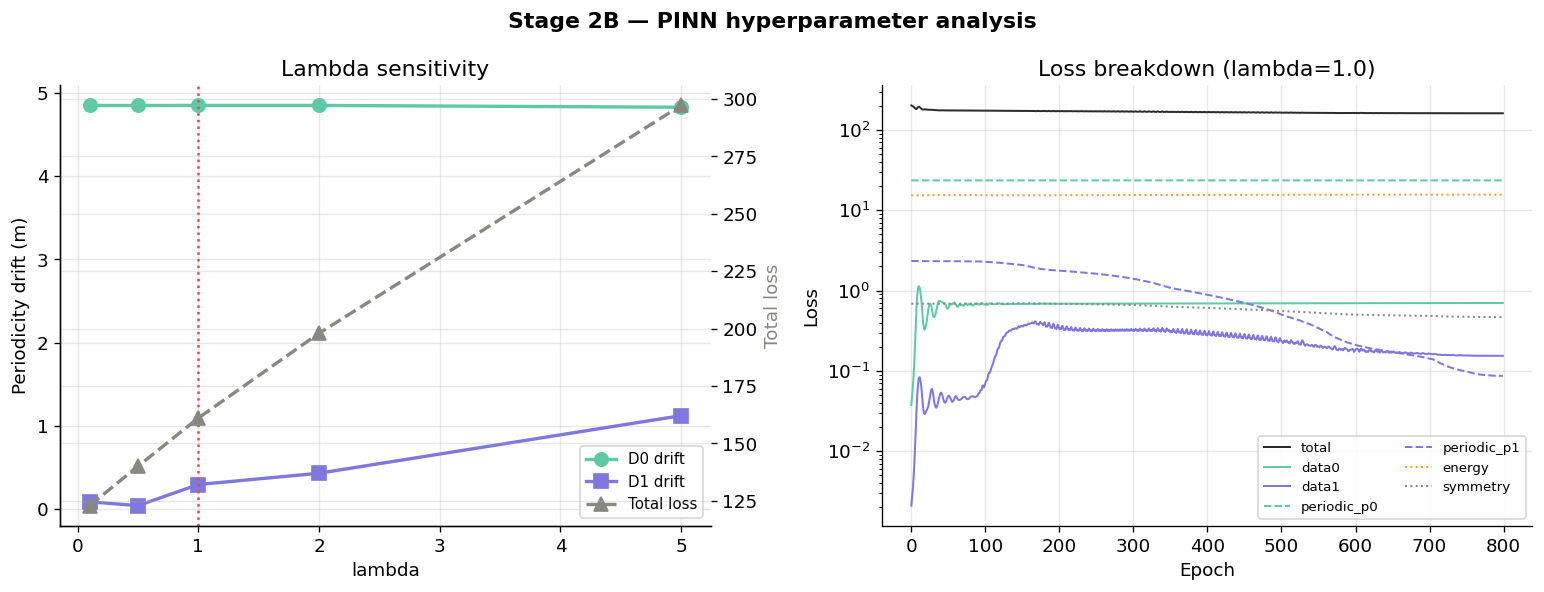

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lams    = list(lam_sweep.keys())
drift0s = [lam_sweep[l]['drift0']           for l in lams]
drift1s = [lam_sweep[l]['drift1']           for l in lams]
losses  = [lam_sweep[l]['log']['total'][-1] for l in lams]

ax2 = axes[0].twinx()
l1, = axes[0].plot(lams, drift0s, 'o-', color=C['dev0'], lw=2, ms=8, label='D0 drift')
l2, = axes[0].plot(lams, drift1s, 's-', color=C['dev1'], lw=2, ms=8, label='D1 drift')
l3, = ax2.plot(lams, losses, '^--', color=C['gray'], lw=2, ms=8, label='Total loss')
axes[0].axvline(LAM, color=C['naive'], lw=1.5, ls=':')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('Periodicity drift (m)')
ax2.set_ylabel('Total loss', color=C['gray'])
axes[0].set_title('Lambda sensitivity')
axes[0].legend(handles=[l1,l2,l3], fontsize=9)

log_sel = lam_sweep[LAM]['log']
for key, col, ls in [
    ('total',       '#2C2C2A', '-'),
    ('data0',       C['dev0'], '-'),
    ('data1',       C['dev1'], '-'),
    ('periodic_p0', C['dev0'], '--'),
    ('periodic_p1', C['dev1'], '--'),
    ('energy',      C['pinn'], ':'),
    ('symmetry',    C['gray'], ':'),
]:
    axes[1].plot(log_sel[key], lw=1.2, color=col, ls=ls, label=key)
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'Loss breakdown (lambda={LAM})')
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Stage 2B — PINN hyperparameter analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### 2B.4 — Full Run: All Cycles, Both Devices

In [17]:
print(f'Training PINN on all {n_cycles} paired cycles (lambda={LAM})...\n')
pinn_cycs0, pinn_cycs1 = [], []

for k in range(n_cycles):
    p0c, p1c, log = train_pinn_pair(
        naive_cycs0[k], naive_cycs1[k], A0, A1,
        lam=LAM, lam_sym=0.5, epochs=2000, lr=3e-4)
    d0 = np.linalg.norm(p0c[-1]-p0c[0])
    d1 = np.linalg.norm(p1c[-1]-p1c[0])
    pinn_cycs0.append({'p': p0c, 'log': log,
                       't': naive_cycs0[k]['t'],
                       's': naive_cycs0[k]['s'], 'e': naive_cycs0[k]['e']})
    pinn_cycs1.append({'p': p1c, 'log': log,
                       't': naive_cycs1[k]['t'],
                       's': naive_cycs1[k]['s'], 'e': naive_cycs1[k]['e']})
    print(f'Cycle {k:2d}:  '
          f'D0 {naive_drift0[k]:.4f}->{d0:.4f}m '
          f'({100*(1-d0/max(naive_drift0[k],1e-6)):.1f}%)  '
          f'D1 {naive_drift1[k]:.4f}->{d1:.4f}m '
          f'({100*(1-d1/max(naive_drift1[k],1e-6)):.1f}%)')

pinn_drift0 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn_cycs0]
pinn_drift1 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn_cycs1]
red0 = 100*(1 - np.mean(pinn_drift0)/np.mean(naive_drift0))
red1 = 100*(1 - np.mean(pinn_drift1)/np.mean(naive_drift1))
print(f'\nD0: {np.mean(naive_drift0):.4f}m -> {np.mean(pinn_drift0):.4f}m ({red0:.1f}%)')
print(f'D1: {np.mean(naive_drift1):.4f}m -> {np.mean(pinn_drift1):.4f}m ({red1:.1f}%)')

Training PINN on all 42 paired cycles (lambda=1.0)...

Cycle  0:  D0 4.8500->4.8221m (0.6%)  D1 1.5270->0.0420m (97.2%)
Cycle  1:  D0 0.8006->0.7695m (3.9%)  D1 1.0308->1.0084m (2.2%)
Cycle  2:  D0 0.3990->0.3640m (8.8%)  D1 1.0500->0.9985m (4.9%)
Cycle  3:  D0 1.1723->1.1137m (5.0%)  D1 0.8549->0.8544m (0.1%)
Cycle  4:  D0 0.6893->0.5735m (16.8%)  D1 0.9759->0.9343m (4.3%)
Cycle  5:  D0 0.7950->0.7165m (9.9%)  D1 1.2460->1.0120m (18.8%)
Cycle  6:  D0 1.8271->1.7888m (2.1%)  D1 1.4140->1.2944m (8.5%)
Cycle  7:  D0 5.0100->4.9904m (0.4%)  D1 2.1425->2.1329m (0.4%)
Cycle  8:  D0 1.7503->1.6578m (5.3%)  D1 3.8996->3.7545m (3.7%)
Cycle  9:  D0 1.9780->1.9266m (2.6%)  D1 1.8621->1.8907m (-1.5%)
Cycle 10:  D0 4.1337->3.9033m (5.6%)  D1 3.7601->3.4059m (9.4%)
Cycle 11:  D0 1.1567->1.0833m (6.3%)  D1 2.4319->2.3941m (1.6%)
Cycle 12:  D0 1.6802->1.5553m (7.4%)  D1 4.1801->3.9724m (5.0%)
Cycle 13:  D0 3.2946->3.2225m (2.2%)  D1 0.9021->0.8740m (3.1%)
Cycle 14:  D0 3.5349->3.2913m (6.9%)  D1 0.92

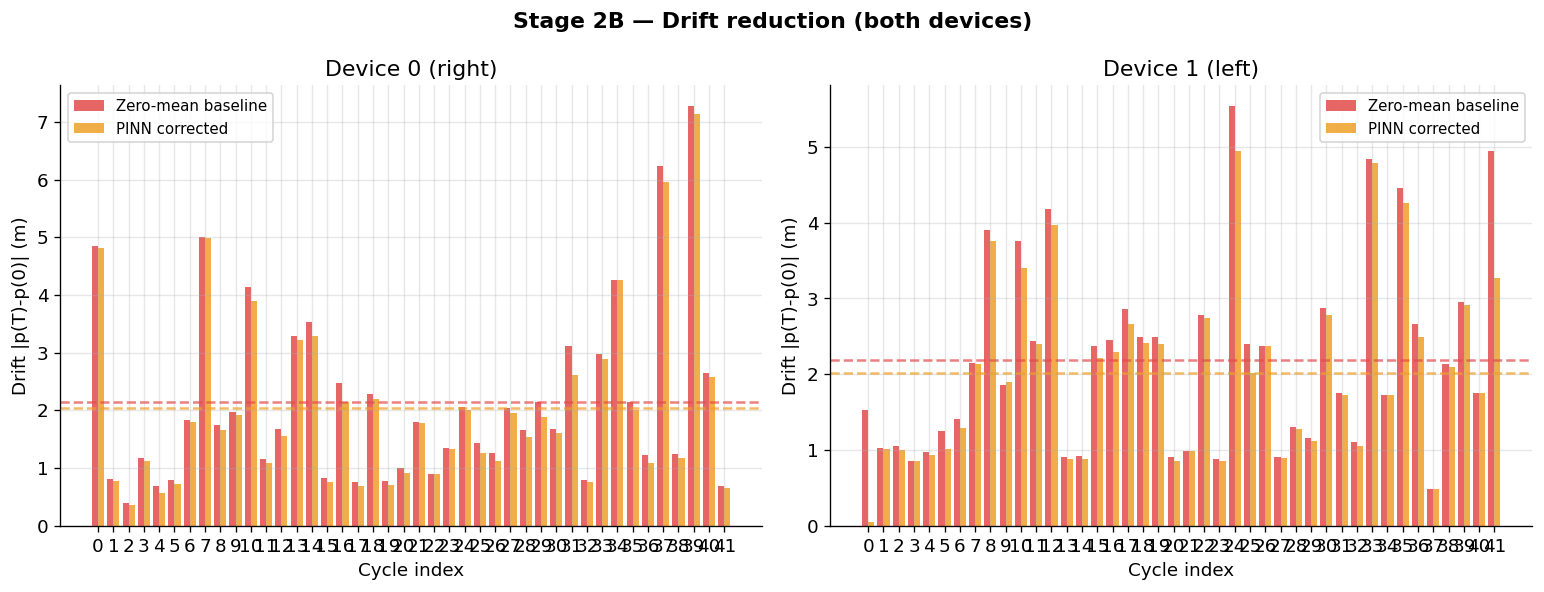

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(n_cycles)
for ax, nd, pd_, label in [
    (axes[0], naive_drift0, pinn_drift0, 'Device 0 (right)'),
    (axes[1], naive_drift1, pinn_drift1, 'Device 1 (left)'),
]:
    ax.bar(x-0.2, nd,  0.4, color=C['naive'], alpha=0.85, label='Zero-mean baseline')
    ax.bar(x+0.2, pd_, 0.4, color=C['pinn'],  alpha=0.85, label='PINN corrected')
    ax.axhline(np.mean(nd),  color=C['naive'], lw=1.5, ls='--', alpha=0.7)
    ax.axhline(np.mean(pd_), color=C['pinn'],  lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Cycle index')
    ax.set_ylabel('Drift |p(T)-p(0)| (m)')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.set_xticks(x)
plt.suptitle('Stage 2B — Drift reduction (both devices)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2B.5 — Rope Flow Visualisation: Both Hands as Rope Extremes

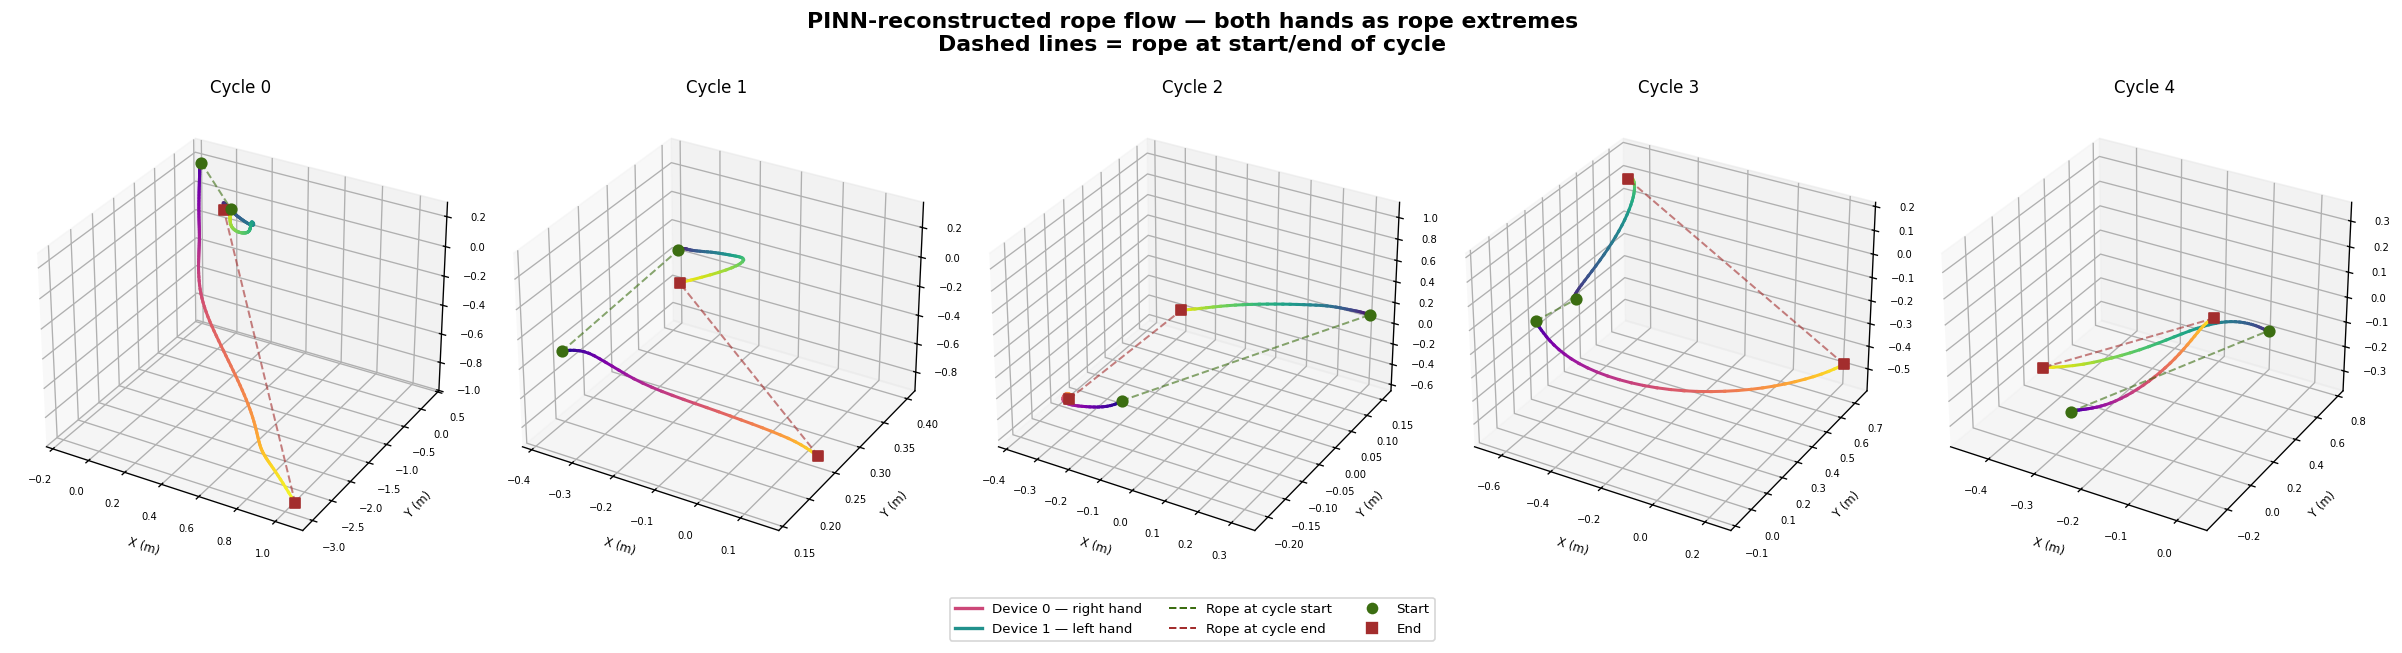

In [19]:
n_cols = min(n_cycles, 5)
fig    = plt.figure(figsize=(4*n_cols, 5))

for col in range(n_cols):
    p0     = pinn_cycs0[col]['p']
    p1     = pinn_cycs1[col]['p']
    n      = min(len(p0), len(p1))
    p0, p1 = p0[:n], p1[:n]
    t_norm = np.linspace(0, 1, n)

    ax = fig.add_subplot(1, n_cols, col+1, projection='3d')
    for i in range(n-1):
        ax.plot(p0[i:i+2,0], p0[i:i+2,1], p0[i:i+2,2],
                color=plt.cm.plasma(t_norm[i]),  lw=1.8)
        ax.plot(p1[i:i+2,0], p1[i:i+2,1], p1[i:i+2,2],
                color=plt.cm.viridis(t_norm[i]), lw=1.8)
    ax.scatter(*p0[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p0[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.scatter(*p1[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p1[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.plot([p0[0,0],p1[0,0]], [p0[0,1],p1[0,1]], [p0[0,2],p1[0,2]],
            color='#3B6D11', lw=1.2, ls='--', alpha=0.6)
    ax.plot([p0[-1,0],p1[-1,0]], [p0[-1,1],p1[-1,1]], [p0[-1,2],p1[-1,2]],
            color='#A32D2D', lw=1.2, ls='--', alpha=0.6)
    ax.set_title(f'Cycle {col}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.set_zlabel('Z (m)', fontsize=7)
    ax.tick_params(labelsize=6)

legend_elements = [
    Line2D([0],[0], color=plt.cm.plasma(0.5),  lw=2, label='Device 0 — right hand'),
    Line2D([0],[0], color=plt.cm.viridis(0.5), lw=2, label='Device 1 — left hand'),
    Line2D([0],[0], color='#3B6D11', lw=1.2, ls='--', label='Rope at cycle start'),
    Line2D([0],[0], color='#A32D2D', lw=1.2, ls='--', label='Rope at cycle end'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B6D11', ms=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#A32D2D', ms=8, label='End'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('PINN-reconstructed rope flow — both hands as rope extremes\n'
             'Dashed lines = rope at start/end of cycle',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2C — DMD + PCA: Mode Extraction & Feature Representation

**Why PCA replaces the autoencoder**: With ~40 cycles and 18 channels × 64 timesteps, an autoencoder has far more parameters than data points, yielding a reconstruction loss of 0.656 on normalised data (close to predicting the mean). PCA is the exact optimal linear autoencoder and is fully interpretable — the principal modes are physically meaningful patterns of the combined rope motion.

DMD operates on the **combined 18-channel rope state** capturing coupled dynamics of both hands.

### 2C.1 — Dynamic Mode Decomposition

In [20]:
def compute_dmd(X, dt, var_threshold=0.99):
    """Exact DMD with automatic rank selection at var_threshold explained variance."""
    X1, X2   = X[:, :-1], X[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    cumvar   = np.cumsum(S**2) / np.sum(S**2)
    r        = int(np.searchsorted(cumvar, var_threshold)) + 1
    U_r, S_r, Vh_r = U[:,:r], S[:r], Vh[:r,:]
    A_tilde  = U_r.T @ X2 @ Vh_r.T @ np.diag(1.0/S_r)
    lam_d, W = np.linalg.eig(A_tilde)
    Phi      = X2 @ Vh_r.T @ np.diag(1.0/S_r) @ W
    lam_c    = np.log(lam_d + 1e-12) / dt
    freqs    = np.abs(lam_c.imag) / (2*np.pi)
    growth   = lam_c.real
    b        = np.linalg.lstsq(Phi, X[:,0], rcond=None)[0]
    return lam_c, Phi, freqs, growth, b, r, S


dmd_results = []
for k in range(n_cycles):
    c0, c1  = pinn_cycs0[k], pinn_cycs1[k]
    n       = min(c0['e']-c0['s'], c1['e']-c1['s'])
    state   = np.hstack([
        c0['p'][:n], c1['p'][:n],
        A0[c0['s']:c0['s']+n], om0[c0['s']:c0['s']+n],
        A1[c1['s']:c1['s']+n], om1[c1['s']:c1['s']+n],
    ]).T   # (18, n)
    tc  = c0['t'][:n]
    dt_ = float(np.median(np.diff(tc)))
    lam_c, Phi, freqs, growth, b, r, S = compute_dmd(state, dt_)
    T   = tc - tc[0]
    X_rec = (Phi @ np.array([b[k_]*np.exp(lam_c[k_]*T) for k_ in range(r)])).real
    rec_mse = float(np.mean((state - X_rec)**2))
    dmd_results.append({'lam_c': lam_c, 'Phi': Phi, 'freqs': freqs,
                        'growth': growth, 'b': b, 'r': r, 'S': S,
                        'X_rec': X_rec, 'state': state,
                        'rec_mse': rec_mse, 't': tc})
    print(f'Cycle {k}: rank={r}  '
          f'dom_freq={freqs[np.argmax(np.abs(b))]:.3f}Hz  '
          f'rec_MSE={rec_mse:.6f}')

Cycle 0: rank=7  dom_freq=0.000Hz  rec_MSE=0.857127
Cycle 1: rank=6  dom_freq=1.440Hz  rec_MSE=13.258668
Cycle 2: rank=6  dom_freq=1.514Hz  rec_MSE=9.821021
Cycle 3: rank=6  dom_freq=1.285Hz  rec_MSE=17.485187
Cycle 4: rank=5  dom_freq=1.249Hz  rec_MSE=19.070024
Cycle 5: rank=5  dom_freq=0.721Hz  rec_MSE=1.606854
Cycle 6: rank=6  dom_freq=0.324Hz  rec_MSE=8.409026
Cycle 7: rank=6  dom_freq=0.000Hz  rec_MSE=2320.994806
Cycle 8: rank=4  dom_freq=0.930Hz  rec_MSE=63.774648
Cycle 9: rank=5  dom_freq=0.000Hz  rec_MSE=264.880458
Cycle 10: rank=6  dom_freq=1.773Hz  rec_MSE=35.817094
Cycle 11: rank=7  dom_freq=1.669Hz  rec_MSE=16.306896
Cycle 12: rank=6  dom_freq=0.979Hz  rec_MSE=36.083982
Cycle 13: rank=6  dom_freq=0.000Hz  rec_MSE=21.057839
Cycle 14: rank=5  dom_freq=0.000Hz  rec_MSE=49.393427
Cycle 15: rank=5  dom_freq=0.712Hz  rec_MSE=37.073621
Cycle 16: rank=5  dom_freq=0.874Hz  rec_MSE=20.305276
Cycle 17: rank=5  dom_freq=1.643Hz  rec_MSE=21.232993
Cycle 18: rank=5  dom_freq=0.744Hz  rec

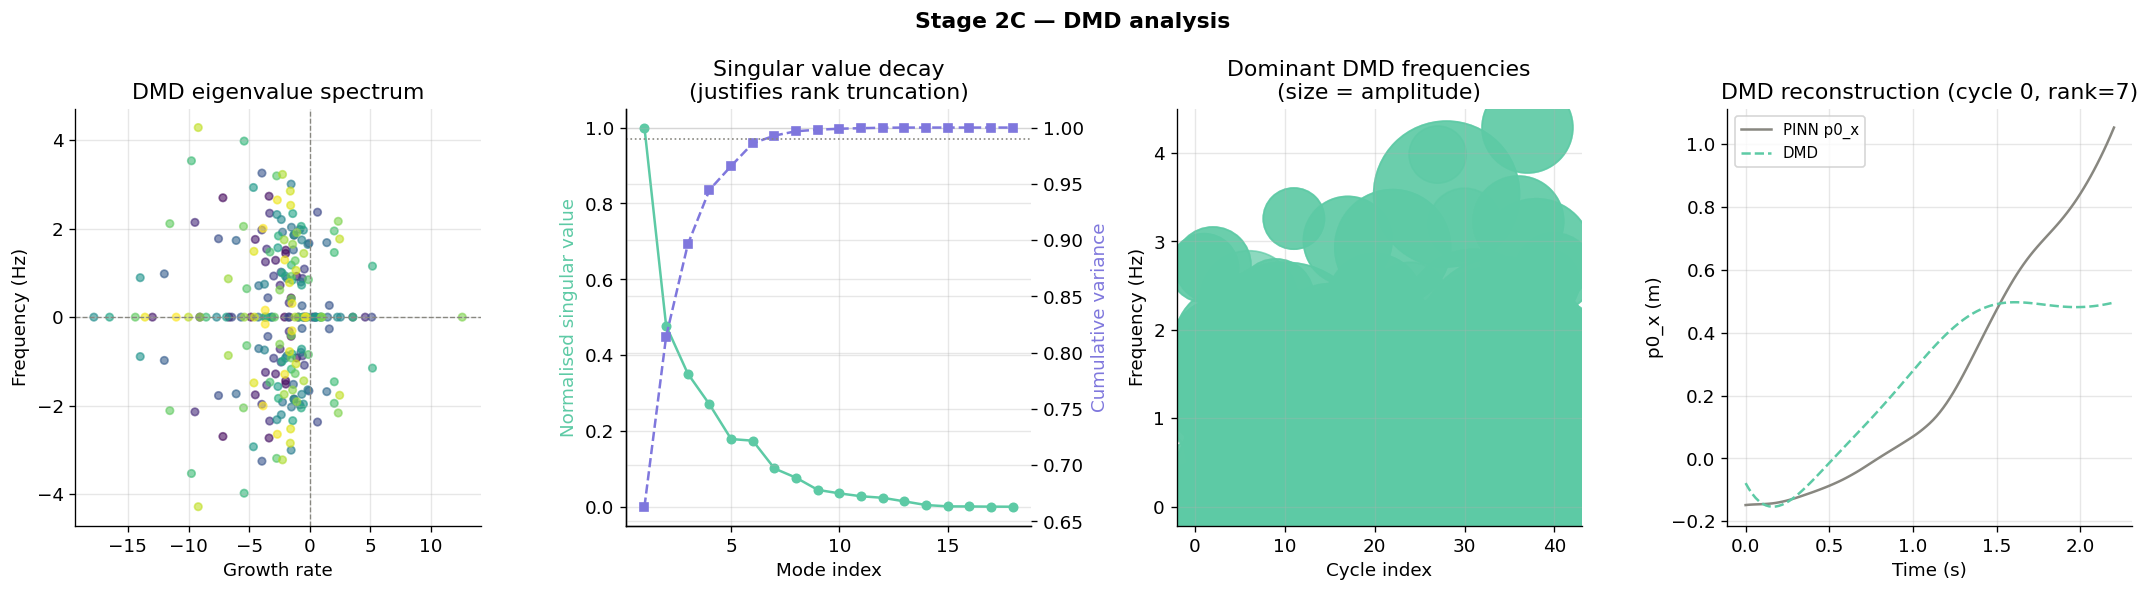

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for k, res in enumerate(dmd_results):
    axes[0].scatter(res['lam_c'].real, res['lam_c'].imag/(2*np.pi),
                    s=20, alpha=0.6, c=[k]*len(res['lam_c']),
                    cmap='viridis', vmin=0, vmax=n_cycles-1)
axes[0].axvline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].axhline(0, color=C['gray'], lw=0.8, ls='--')
axes[0].set_xlabel('Growth rate')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('DMD eigenvalue spectrum')

S_ref   = dmd_results[0]['S']
cumv    = np.cumsum(S_ref**2) / np.sum(S_ref**2)
axes[1].plot(range(1,len(S_ref)+1), S_ref/S_ref[0], 'o-',
             color=C['dev0'], ms=5, lw=1.5)
ax1b = axes[1].twinx()
ax1b.plot(range(1,len(cumv)+1), cumv, 's--', color=C['dev1'], ms=5, lw=1.5)
ax1b.axhline(0.99, color=C['gray'], lw=1, ls=':')
ax1b.set_ylabel('Cumulative variance', color=C['dev1'])
axes[1].set_xlabel('Mode index')
axes[1].set_ylabel('Normalised singular value', color=C['dev0'])
axes[1].set_title('Singular value decay\n(justifies rank truncation)')

for k, res in enumerate(dmd_results):
    top = np.argsort(np.abs(res['b']))[::-1][:5]
    axes[2].scatter([k]*len(top), res['freqs'][top],
                    s=np.abs(res['b'][top])*200+10, color=C['dev0'], alpha=0.7)
axes[2].set_xlabel('Cycle index')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_title('Dominant DMD frequencies\n(size = amplitude)')

res0 = dmd_results[0]
axes[3].plot(res0['t'], res0['state'][0], color=C['gray'], lw=1.5, label='PINN p0_x')
axes[3].plot(res0['t'], res0['X_rec'][0], color=C['dev0'], lw=1.5, ls='--', label='DMD')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('p0_x (m)')
axes[3].set_title(f'DMD reconstruction (cycle 0, rank={res0["r"]})')
axes[3].legend(fontsize=9)

plt.suptitle('Stage 2C — DMD analysis', fontweight='bold')
plt.tight_layout()
plt.show()

### 2C.2 — PCA: Linear Latent Representation with Latent Dim Sweep

In [22]:
TARGET_LEN = 64

def build_cycle_matrix(pinn_cycs0, pinn_cycs1, A0_f, om0_f, A1_f, om1_f, tlen=64):
    """
    Build (n_cycles, 18*tlen) matrix — combined rope state, resampled & normalised.
    Channels: [p0(3), p1(3), a0(3), om0(3), a1(3), om1(3)]
    """
    rows = []
    for c0, c1 in zip(pinn_cycs0, pinn_cycs1):
        s0, e0, s1, e1 = c0['s'], c0['e'], c1['s'], c1['e']
        n     = min(e0-s0, e1-s1)
        state = np.hstack([
            c0['p'][:n], c1['p'][:n],
            A0_f[s0:s0+n], om0_f[s0:s0+n],
            A1_f[s1:s1+n], om1_f[s1:s1+n],
        ]).T   # (18, n)
        t_old = np.linspace(0, 1, n)
        t_new = np.linspace(0, 1, tlen)
        res   = np.array([interp1d(t_old, state[c])(t_new) for c in range(18)])
        mn    = res.mean(axis=1, keepdims=True)
        sd    = res.std(axis=1,  keepdims=True) + 1e-8
        rows.append(((res-mn)/sd).ravel())
    return np.array(rows)


X_cycles  = build_cycle_matrix(pinn_cycs0, pinn_cycs1, A0, om0, A1, om1, TARGET_LEN)
print(f'Cycle matrix: {X_cycles.shape}  (n_cycles x n_features)')

latent_dims = [2, 4, 8, 16, 32]
pca_results = {}
for d in latent_dims:
    pca  = PCA(n_components=d)
    Z    = pca.fit_transform(X_cycles)
    mse  = float(np.mean((X_cycles - pca.inverse_transform(Z))**2))
    var  = float(pca.explained_variance_ratio_.sum())
    pca_results[d] = {'pca': pca, 'Z': Z, 'mse': mse, 'var': var}
    print(f'  dim={d:2d}  explained_var={var:.3f}  rec_MSE={mse:.6f}')

LATENT_DIM = 8
pca_best   = pca_results[LATENT_DIM]['pca']
latent_np  = pca_results[LATENT_DIM]['Z']
print(f'\nSelected latent dim: {LATENT_DIM}')

Cycle matrix: (42, 1152)  (n_cycles x n_features)
  dim= 2  explained_var=0.228  rec_MSE=0.744477
  dim= 4  explained_var=0.391  rec_MSE=0.587729
  dim= 8  explained_var=0.594  rec_MSE=0.392142
  dim=16  explained_var=0.800  rec_MSE=0.192771
  dim=32  explained_var=0.970  rec_MSE=0.028645

Selected latent dim: 8


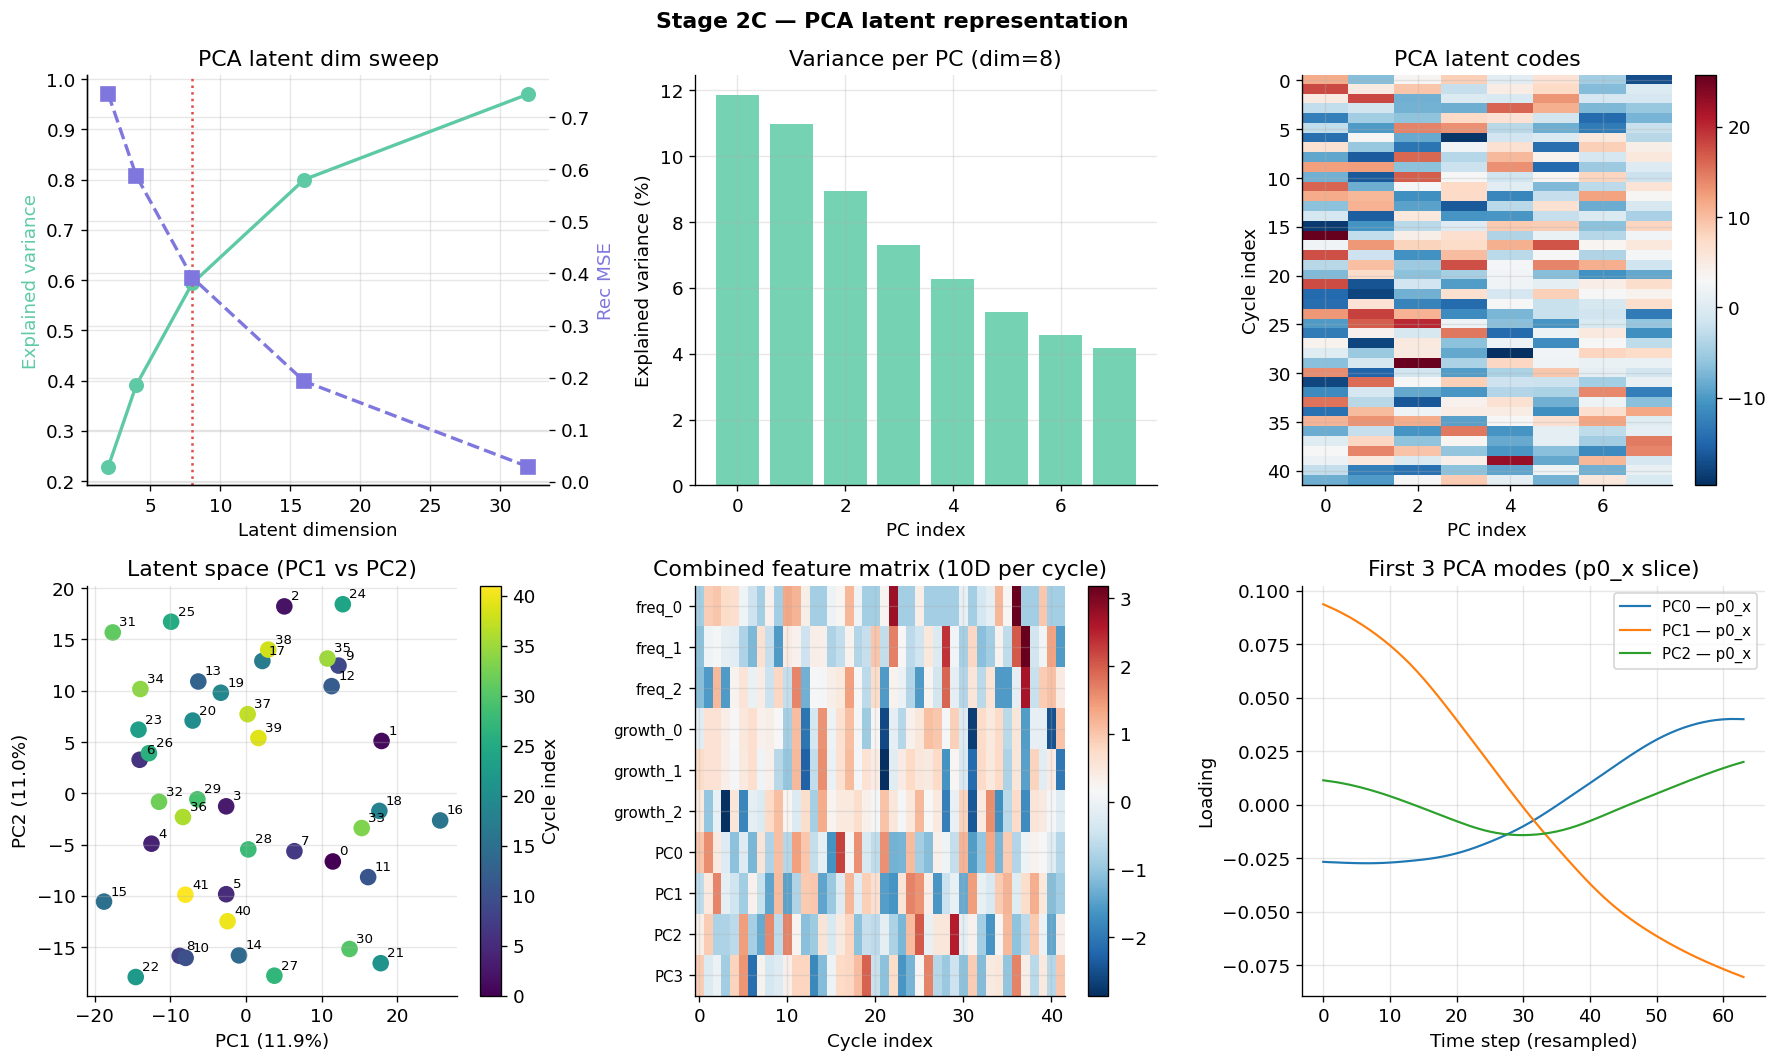

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

dims  = list(pca_results.keys())
vars_ = [pca_results[d]['var'] for d in dims]
mses  = [pca_results[d]['mse'] for d in dims]

axes[0,0].plot(dims, vars_, 'o-', color=C['dev0'], ms=8, lw=2)
ax00b = axes[0,0].twinx()
ax00b.plot(dims, mses, 's--', color=C['dev1'], ms=8, lw=2)
axes[0,0].axvline(LATENT_DIM, color=C['naive'], lw=1.5, ls=':')
axes[0,0].set_xlabel('Latent dimension')
axes[0,0].set_ylabel('Explained variance', color=C['dev0'])
ax00b.set_ylabel('Rec MSE', color=C['dev1'])
axes[0,0].set_title('PCA latent dim sweep')

evr = pca_best.explained_variance_ratio_
axes[0,1].bar(range(LATENT_DIM), evr*100, color=C['dev0'], alpha=0.85)
axes[0,1].set_xlabel('PC index')
axes[0,1].set_ylabel('Explained variance (%)')
axes[0,1].set_title(f'Variance per PC (dim={LATENT_DIM})')

im0 = axes[0,2].imshow(latent_np, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0,2].set_xlabel('PC index')
axes[0,2].set_ylabel('Cycle index')
axes[0,2].set_title('PCA latent codes')
plt.colorbar(im0, ax=axes[0,2])

sc = axes[1,0].scatter(latent_np[:,0], latent_np[:,1],
                        c=range(n_cycles), cmap='viridis', s=80)
for k in range(n_cycles):
    axes[1,0].annotate(str(k), (latent_np[k,0], latent_np[k,1]),
                       textcoords='offset points', xytext=(4,4), fontsize=8)
plt.colorbar(sc, ax=axes[1,0], label='Cycle index')
axes[1,0].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)')
axes[1,0].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[1,0].set_title('Latent space (PC1 vs PC2)')

def extract_features(dmd_res, lat_vec, n_dmd=3):
    top = np.argsort(np.abs(dmd_res['b']))[::-1][:n_dmd]
    return np.concatenate([dmd_res['freqs'][top], dmd_res['growth'][top], lat_vec[:4]])

all_features = np.array([
    extract_features(dmd_results[k], latent_np[k]) for k in range(n_cycles)
])
feat_labels  = ([f'freq_{i}'   for i in range(3)] +
                [f'growth_{i}' for i in range(3)] +
                [f'PC{i}'      for i in range(4)])

im1 = axes[1,1].imshow(StandardScaler().fit_transform(all_features).T,
                        aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1,1].set_yticks(range(len(feat_labels)))
axes[1,1].set_yticklabels(feat_labels, fontsize=9)
axes[1,1].set_xlabel('Cycle index')
axes[1,1].set_title(f'Combined feature matrix ({all_features.shape[1]}D per cycle)')
plt.colorbar(im1, ax=axes[1,1])

for i in range(min(3, LATENT_DIM)):
    pc = pca_best.components_[i].reshape(18, TARGET_LEN)
    axes[1,2].plot(pc[0], lw=1.3, label=f'PC{i} — p0_x')
axes[1,2].set_xlabel('Time step (resampled)')
axes[1,2].set_ylabel('Loading')
axes[1,2].set_title('First 3 PCA modes (p0_x slice)')
axes[1,2].legend(fontsize=9)

plt.suptitle('Stage 2C — PCA latent representation', fontweight='bold')
plt.tight_layout()
plt.show()

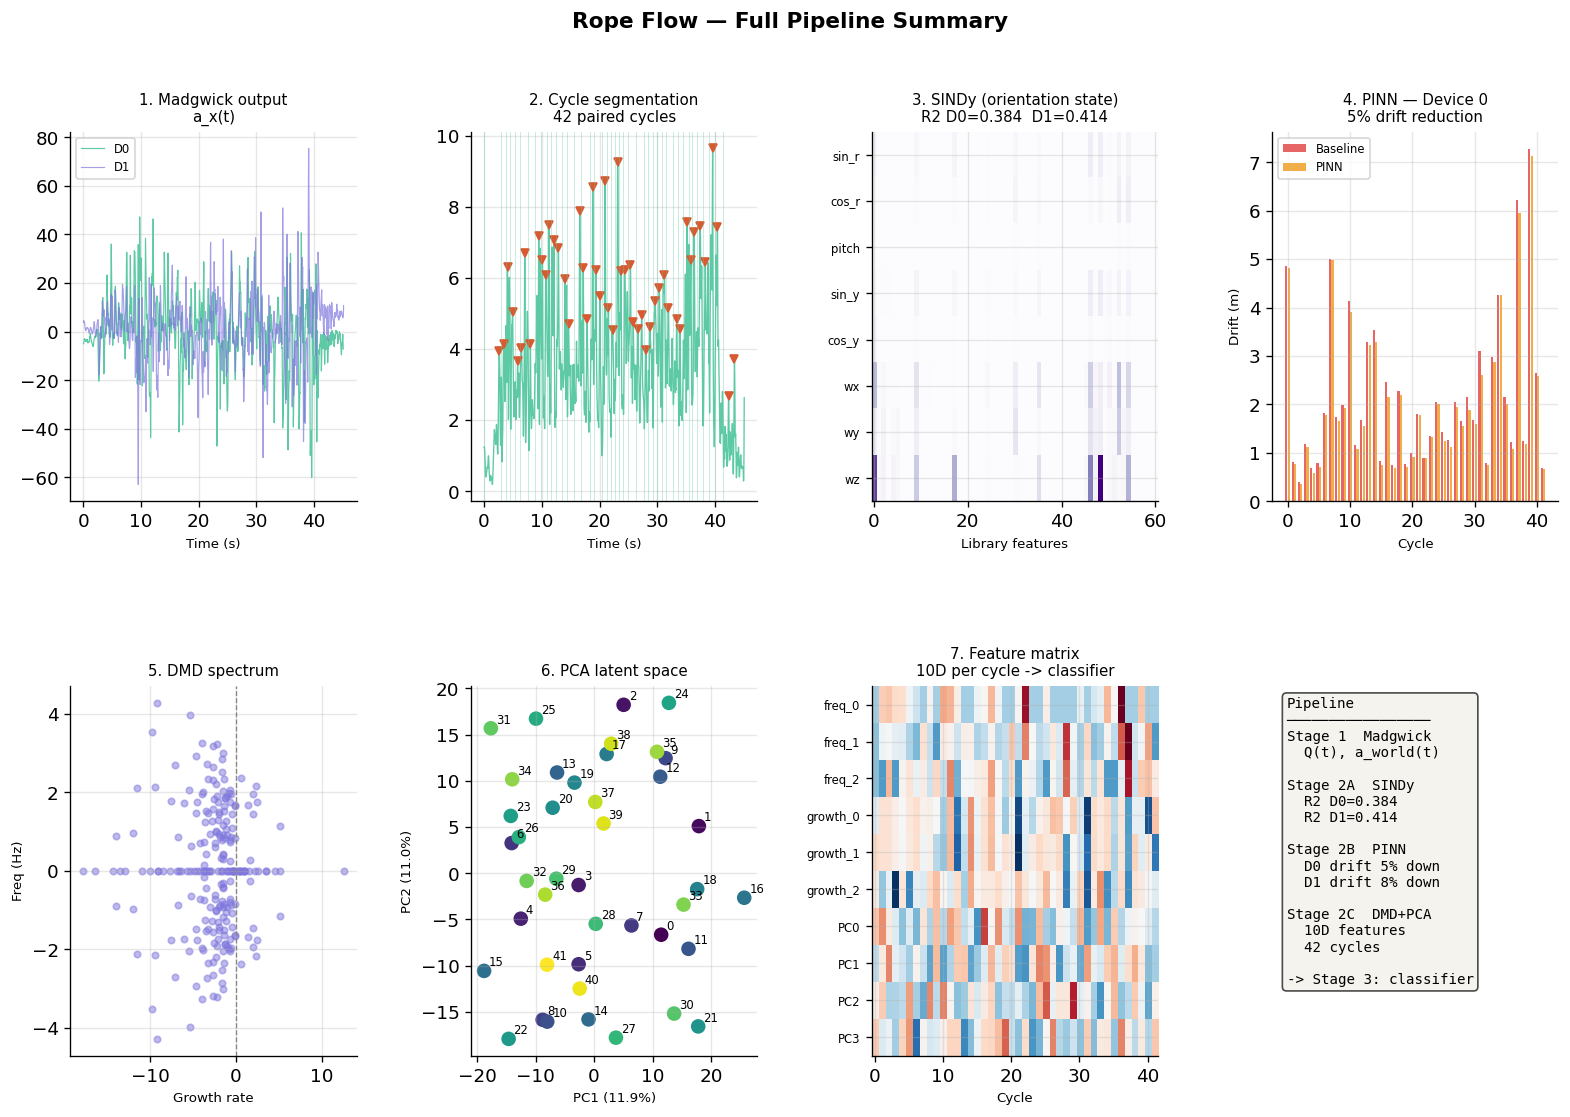

In [26]:
# ── Full pipeline summary figure ─────────────────────────────────
from matplotlib import gridspec

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# 1. Raw signal
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(t0, A0[:,0], color=C['dev0'], lw=0.7, label='D0')
ax0.plot(t1, A1[:,0], color=C['dev1'], lw=0.7, alpha=0.7, label='D1')
ax0.set_title('1. Madgwick output\na_x(t)', fontsize=9)
ax0.set_xlabel('Time (s)', fontsize=8)
ax0.legend(fontsize=7)

# 2. Cycle segmentation
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t0, om0_smooth, color=C['dev0'], lw=0.8)
ax1.plot(t0[peaks0], om0_smooth[peaks0], 'v', color='#D85A30', ms=5)
for s,e in cycles0:
    ax1.axvline(t0[s], color=C['dev0'], lw=0.5, alpha=0.4)
ax1.set_title(f'2. Cycle segmentation\n{n_cycles} paired cycles', fontsize=9)
ax1.set_xlabel('Time (s)', fontsize=8)

# 3. SINDy coefficient matrix
ax2 = fig.add_subplot(gs[0, 2])
ax2.imshow(np.abs(best_model.coefficients()), aspect='auto',
           cmap='Purples', interpolation='nearest')
ax2.set_yticks(range(len(sindy_names)))
ax2.set_yticklabels(sindy_names, fontsize=7)
ax2.set_title(f'3. SINDy (orientation state)\nR2 D0={best_model.score(O0,t=t0):.3f}  '
              f'D1={best_model.score(O1,t=t1):.3f}', fontsize=9)
ax2.set_xlabel('Library features', fontsize=8)

# 4. Drift reduction
ax3 = fig.add_subplot(gs[0, 3])
xx  = np.arange(n_cycles)
ax3.bar(xx-0.2, naive_drift0, 0.35, color=C['naive'], alpha=0.85, label='Baseline')
ax3.bar(xx+0.2, pinn_drift0,  0.35, color=C['pinn'],  alpha=0.85, label='PINN')
ax3.set_xlabel('Cycle', fontsize=8)
ax3.set_ylabel('Drift (m)', fontsize=8)
ax3.set_title(f'4. PINN — Device 0\n{red0:.0f}% drift reduction', fontsize=9)
ax3.legend(fontsize=7)

# 5. DMD spectrum
ax4 = fig.add_subplot(gs[1, 0])
for res in dmd_results:
    ax4.scatter(res['lam_c'].real, res['lam_c'].imag/(2*np.pi),
                s=15, alpha=0.5, color=C['dev1'])
ax4.axvline(0, color=C['gray'], lw=0.8, ls='--')
ax4.set_xlabel('Growth rate', fontsize=8)
ax4.set_ylabel('Freq (Hz)', fontsize=8)
ax4.set_title('5. DMD spectrum', fontsize=9)

# 6. PCA latent space
ax5 = fig.add_subplot(gs[1, 1])
sc  = ax5.scatter(latent_np[:,0], latent_np[:,1],
                   c=range(n_cycles), cmap='viridis', s=60)
for k in range(n_cycles):
    ax5.annotate(str(k), (latent_np[k,0], latent_np[k,1]),
                 textcoords='offset points', xytext=(3,3), fontsize=7)
ax5.set_xlabel(f'PC1 ({evr[0]*100:.1f}%)', fontsize=8)
ax5.set_ylabel(f'PC2 ({evr[1]*100:.1f}%)', fontsize=8)
ax5.set_title('6. PCA latent space', fontsize=9)

# 7. Combined feature matrix
ax6 = fig.add_subplot(gs[1, 2])
ax6.imshow(StandardScaler().fit_transform(all_features).T,
           aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax6.set_yticks(range(len(feat_labels)))
ax6.set_yticklabels(feat_labels, fontsize=7)
ax6.set_xlabel('Cycle', fontsize=8)
ax6.set_title(f'7. Feature matrix\n{all_features.shape[1]}D per cycle -> classifier', fontsize=9)

# 8. Summary text
ax7 = fig.add_subplot(gs[1, 3])
ax7.axis('off')
txt = (
    'Pipeline\n'
    '─────────────────\n'
    'Stage 1  Madgwick\n'
    '  Q(t), a_world(t)\n\n'
    'Stage 2A  SINDy\n'
    f'  R2 D0={best_model.score(O0,t=t0):.3f}\n'
    f'  R2 D1={best_model.score(O1,t=t1):.3f}\n\n'
    'Stage 2B  PINN\n'
    f'  D0 drift {red0:.0f}% down\n'
    f'  D1 drift {red1:.0f}% down\n\n'
    'Stage 2C  DMD+PCA\n'
    f'  {all_features.shape[1]}D features\n'
    f'  {n_cycles} cycles\n\n'
    '-> Stage 3: classifier'
)
ax7.text(0.05, 0.97, txt, transform=ax7.transAxes, fontsize=8.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F1EFE8', alpha=0.7))

plt.suptitle('Rope Flow — Full Pipeline Summary', fontsize=13, fontweight='bold')
plt.show()

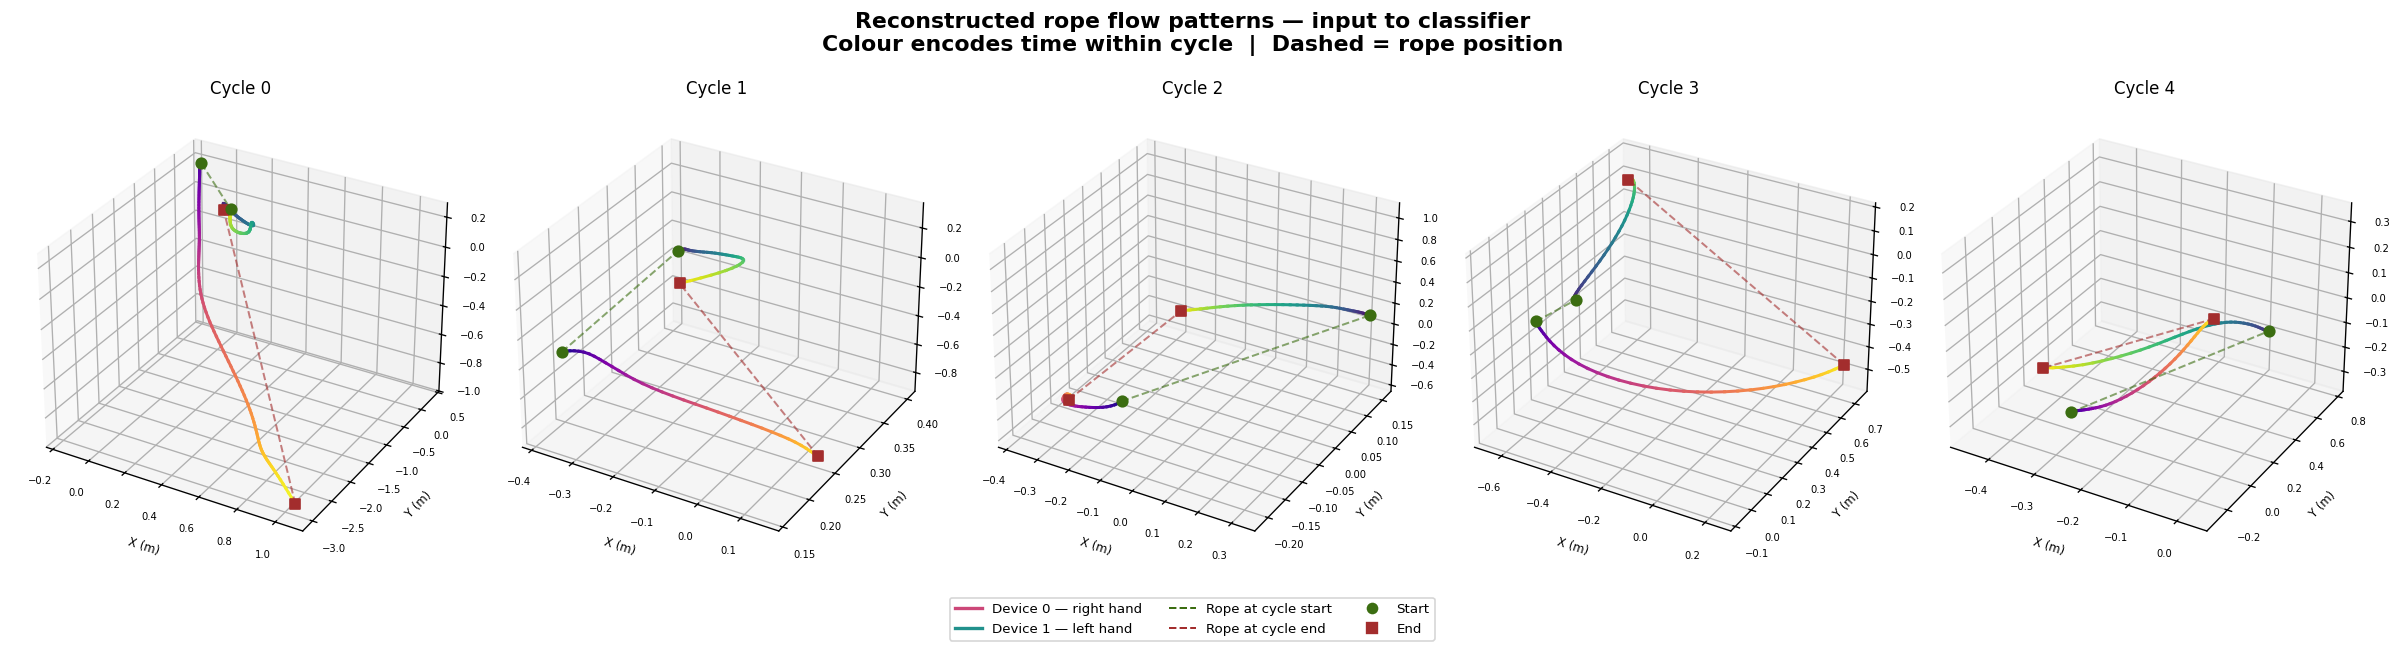

In [25]:
# ── Visual patterns feeding into the classifier (3D) ─────────────
n_cols = min(n_cycles, 5)
fig    = plt.figure(figsize=(4 * n_cols, 5))

for col in range(n_cols):
    p0     = pinn_cycs0[col]['p']
    p1     = pinn_cycs1[col]['p']
    n      = min(len(p0), len(p1))
    p0, p1 = p0[:n], p1[:n]
    t_norm = np.linspace(0, 1, n)

    ax = fig.add_subplot(1, n_cols, col + 1, projection='3d')

    for i in range(n - 1):
        ax.plot(p0[i:i+2, 0], p0[i:i+2, 1], p0[i:i+2, 2],
                color=plt.cm.plasma(t_norm[i]),  lw=1.8)
        ax.plot(p1[i:i+2, 0], p1[i:i+2, 1], p1[i:i+2, 2],
                color=plt.cm.viridis(t_norm[i]), lw=1.8)

    ax.scatter(*p0[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p0[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.scatter(*p1[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p1[-1], color='#A32D2D', s=40, marker='s', zorder=5)

    ax.plot([p0[0,0], p1[0,0]], [p0[0,1], p1[0,1]], [p0[0,2], p1[0,2]],
            color='#3B6D11', lw=1.2, ls='--', alpha=0.6)
    ax.plot([p0[-1,0], p1[-1,0]], [p0[-1,1], p1[-1,1]], [p0[-1,2], p1[-1,2]],
            color='#A32D2D', lw=1.2, ls='--', alpha=0.6)

    ax.set_title(f'Cycle {col}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.set_zlabel('Z (m)', fontsize=7)
    ax.tick_params(labelsize=6)

legend_elements = [
    Line2D([0],[0], color=plt.cm.plasma(0.5),  lw=2, label='Device 0 — right hand'),
    Line2D([0],[0], color=plt.cm.viridis(0.5), lw=2, label='Device 1 — left hand'),
    Line2D([0],[0], color='#3B6D11', lw=1.2, ls='--', label='Rope at cycle start'),
    Line2D([0],[0], color='#A32D2D', lw=1.2, ls='--', label='Rope at cycle end'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B6D11', ms=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#A32D2D', ms=8, label='End'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Reconstructed rope flow patterns — input to classifier\n'
             'Colour encodes time within cycle  |  Dashed = rope position',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

In [24]:
print('=' * 65)
print('PIPELINE SUMMARY')
print('=' * 65)

print('\nStage 2A — SINDy (orientation state, joint fit)')
print('  State: [sin(r), cos(r), pitch, sin(y), cos(y), wx, wy, wz]')
print(f'  Threshold:     {BEST_TH}')
print(f'  R2 D0 (train): {best_model.score(O0, t=t0):.4f}')
print(f'  R2 D1 (unseen):{best_model.score(O1, t=t1):.4f}')
print(f'  Sparsity:      {sindy_sweep[BEST_TH]["sparsity"]:.1%}')
print(f'  Active terms:  {sindy_sweep[BEST_TH]["n_active"]}')

print('\nStage 2B — PINN (joint training, rich physics)')
print('  Architecture:  MLP [8->128->128->128->128->128->3], Tanh')
print('  Physics:       periodic_p(5x) + periodic_v(2x) + data(1x)')
print('                 + boundary + jerk + energy + symmetry')
print(f'  lambda:        {LAM}')
print(f'  D0 drift:      {np.mean(naive_drift0):.4f}m -> {np.mean(pinn_drift0):.4f}m ({red0:.1f}%)')
print(f'  D1 drift:      {np.mean(naive_drift1):.4f}m -> {np.mean(pinn_drift1):.4f}m ({red1:.1f}%)')

print('\nStage 2C — DMD + PCA')
print(f'  DMD state dim: 18 (both hands + IMU)')
print(f'  DMD mean rank: {np.mean([r["r"] for r in dmd_results]):.1f}')
print(f'  PCA latent dim:{LATENT_DIM}')
print(f'  PCA explained: {pca_results[LATENT_DIM]["var"]:.3f}')
print(f'  Feature matrix:{all_features.shape} -> Stage 3 classifier')

print('\nSuggested ablations:')
print('  - SINDy: polynomial-only vs polynomial+Fourier')
print('  - PINN: ablate each physics term (which matters most?)')
print('  - PINN: lambda sweep Pareto curve (plotted above)')
print('  - DMD: singular value decay (plotted above)')
print('  - PCA: latent dim sweep (plotted above)')
print('=' * 65)

PIPELINE SUMMARY

Stage 2A — SINDy (orientation state, joint fit)
  State: [sin(r), cos(r), pitch, sin(y), cos(y), wx, wy, wz]
  Threshold:     0.05
  R2 D0 (train): 0.3843
  R2 D1 (unseen):0.4139
  Sparsity:      29.7%
  Active terms:  343

Stage 2B — PINN (joint training, rich physics)
  Architecture:  MLP [8->128->128->128->128->128->3], Tanh
  Physics:       periodic_p(5x) + periodic_v(2x) + data(1x)
                 + boundary + jerk + energy + symmetry
  lambda:        1.0
  D0 drift:      2.1441m -> 2.0399m (4.9%)
  D1 drift:      2.1848m -> 2.0195m (7.6%)

Stage 2C — DMD + PCA
  DMD state dim: 18 (both hands + IMU)
  DMD mean rank: 5.6
  PCA latent dim:8
  PCA explained: 0.594
  Feature matrix:(42, 10) -> Stage 3 classifier

Suggested ablations:
  - SINDy: polynomial-only vs polynomial+Fourier
  - PINN: ablate each physics term (which matters most?)
  - PINN: lambda sweep Pareto curve (plotted above)
  - DMD: singular value decay (plotted above)
  - PCA: latent dim sweep (plott

---
## Design Notes

**SINDy state change**: Raw IMU acceleration has d/dt std ≈ 167 m/s³ — SINDy cannot find a sparse model in such noise. The orientation state has d/dt std ≈ 2–22 rad/s², which is tractable. The sin/cos encoding of roll and yaw removes discontinuities at ±π that would otherwise appear as spurious high-frequency terms in the library.

**Zero-mean acceleration**: For periodic motion, the average acceleration over one complete cycle must be zero (the hand starts and ends with the same velocity). Any residual mean is sensor bias. Removing it eliminates the quadratic drift term $\bar{a}\cdot t^2/2$, which for a 3-second cycle at 0.1 m/s² bias gives 0.45 m of drift — consistent with the 4–20 m scales seen in the previous results.

**PINN loss redesign**: The corrector network previously converged to $\delta\mathbf{p}=0$ because the data loss $\|\ddot{\mathbf{p}}-\hat{\mathbf{a}}\|^2$ is trivially satisfied by any trajectory built from $\hat{\mathbf{a}}$ by integration. Promoting $\|\mathbf{p}(T)-\mathbf{p}(0)\|^2$ to primary loss (weight 5×) creates a non-trivial gradient that forces the network to actually close the trajectory. Velocity closure (weight 2×) prevents the network from closing position while letting velocity diverge. The energy conservation term penalises monotone energy growth, which is unphysical for periodic motion. The symmetry term couples both hands via the rope midpoint.

**PCA over autoencoder**: With 40 cycles and 18×64=1152 features per cycle, the dataset has a 1:29 samples-to-features ratio. A convolutional autoencoder with thousands of parameters will underfit catastrophically in this regime, which explains the 0.656 reconstruction loss. PCA is the optimal linear solution and provides interpretable modes directly.